### Import libraries and datasets

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import keras
import random
import matplotlib.pyplot as plt

from joblib import dump, load
from os import path
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.pyplot import *
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from keras.models import Sequential
from keras import Model, Input, layers, optimizers
from keras.layers import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

Normal training dataset

In [ ]:
# Read the CSV file into a DataFrame
path = r'../CIC-IDS/CSV-2023/MERGED_CSV'
all_files = glob.glob(path + "/*.csv")
li = []
for i in range(45):
    df = pd.read_csv(all_files[i], encoding='cp1252', index_col=None, header=0)
    li.append(df)
    print("Read Completed for ", all_files[i])
df = pd.concat(li, axis=0, ignore_index=True)
df.describe()
df.head()
df.info()

Filtered, categorized data by labels for more customized training

In [ ]:
# Attack data
Label_path = r'../Label_CSV'
rows = 300000
# Label_path = r'../Label_CSV'
Brute_Force = pd.read_csv(Label_path + '/Brute_Force.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Brute_Force.csv')
DDoS = pd.read_csv(Label_path + '/DDoS.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/DDoS.csv')
DoS = pd.read_csv(Label_path + '/DoS.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/DoS.csv')
Spoofing = pd.read_csv(Label_path + '/Spoofing.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Spoofing.csv')
Recon = pd.read_csv(Label_path + '/Recon.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Recon.csv')
Web_based = pd.read_csv(Label_path + '/Web_based.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Web_based.csv')
Mirai = pd.read_csv(Label_path + '/Mirai.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Mirai.csv')
list_attack = [DDoS, DoS, Spoofing, Recon, Mirai, Brute_Force, Web_based]
attack = pd.concat(list_attack, axis=0, ignore_index=True)
attack = attack.sample(frac=1, random_state=42).reset_index(drop=True)
label_series = pd.Series(attack['Label'])
print(label_series.value_counts())


# Normal data
path = r'../normal_traffic_cap_live'
all_normal_files = glob.glob(path + "/*.csv")
list_normal = []
for file in all_normal_files:
    normal = pd.read_csv(file, encoding='cp1252', index_col=None, header=0)
    list_normal.append(normal)
    print("Read Completed for ", file)
normal = pd.concat(list_normal, axis=0, ignore_index=True)
normal = normal.drop(columns=['ts'])
normal['Label'] = 0
normal.drop_duplicates(keep='first', inplace = True)
normal.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal.reset_index(drop=True, inplace=True)
# normal = pd.read_csv('../Label_CSV/BENIGN.csv')
# normal = pd.read_csv('c:/Users/ADMIN/Downloads/live_features.csv')

print("Normal: ",normal.shape)
print("Attack: ",attack.shape)

Read Completed for  ../Label_CSV/Brute_Force.csv
Read Completed for  ../Label_CSV/DDoS.csv
Read Completed for  ../Label_CSV/DoS.csv
Read Completed for  ../Label_CSV/Spoofing.csv
Read Completed for  ../Label_CSV/Recon.csv
Read Completed for  ../Label_CSV/Web_based.csv
Read Completed for  ../Label_CSV/Mirai.csv
Label
Mirai          300000
DoS            300000
DDoS           300000
Recon          300000
Spoofing       187208
Web_based       16053
Brute_Force      8733
Name: count, dtype: int64
Read Completed for  ../normal_traffic_cap_live\live_features_1.csv
Read Completed for  ../normal_traffic_cap_live\live_features_2.csv
Read Completed for  ../normal_traffic_cap_live\live_features_3.csv
Read Completed for  ../normal_traffic_cap_live\live_features_4.csv
Read Completed for  ../normal_traffic_cap_live\live_features_5.csv
Read Completed for  ../normal_traffic_cap_live\live_features_6.csv
Read Completed for  ../normal_traffic_cap_live\live_features_7.csv
Read Completed for  ../normal_traf

### 1st satge model (binary classification)

Ensure column align

In [33]:
common_columns = attack.columns.intersection(normal.columns)
attack = attack[common_columns]
normal = normal[common_columns]

Visual Compare Feature Distributions

Header_Length
Normal:  1474280
Attack:  1411994


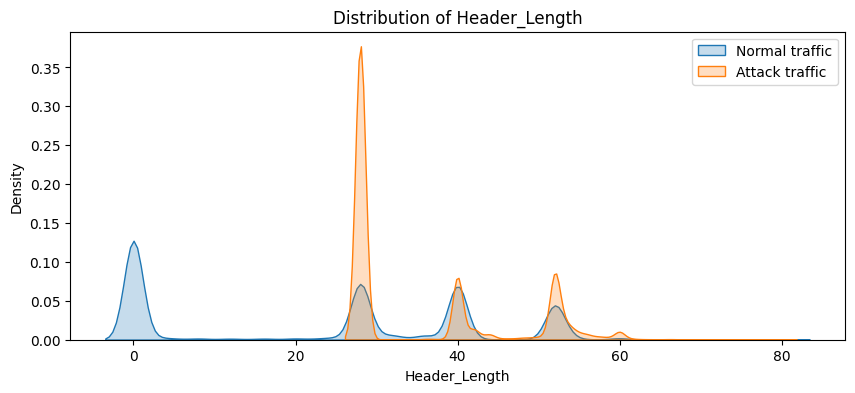

Protocol Type
Normal:  1474280
Attack:  1411994


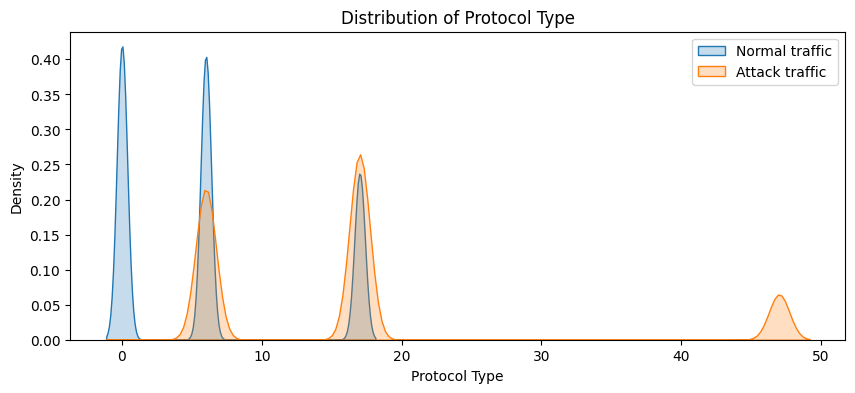

Time_To_Live
Normal:  1474280
Attack:  1411994


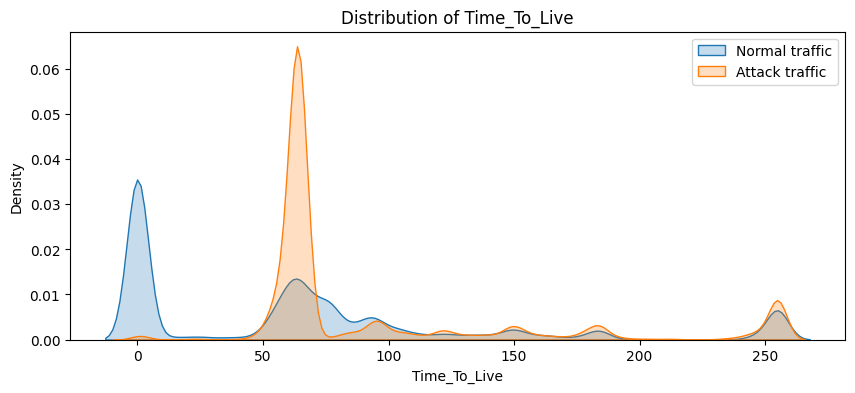

Rate
Normal:  1474280
Attack:  1411994


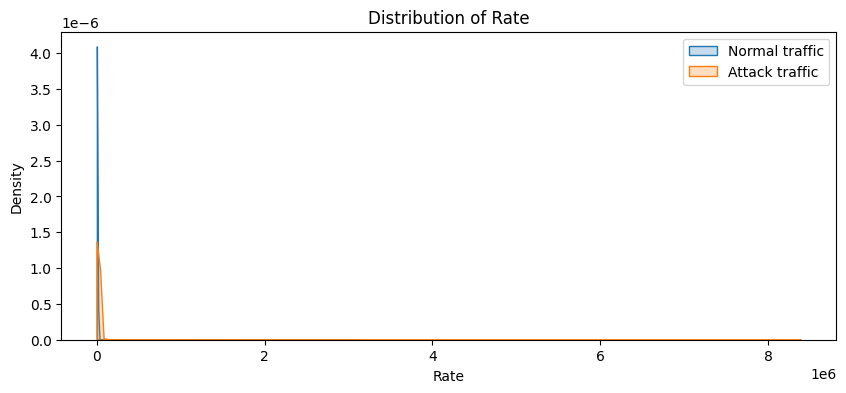

fin_flag_number
Normal:  1474280
Attack:  1411994


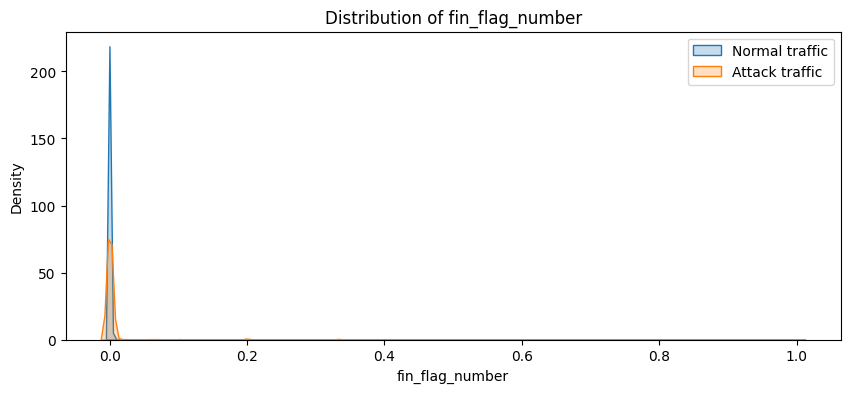

syn_flag_number
Normal:  1474280
Attack:  1411994


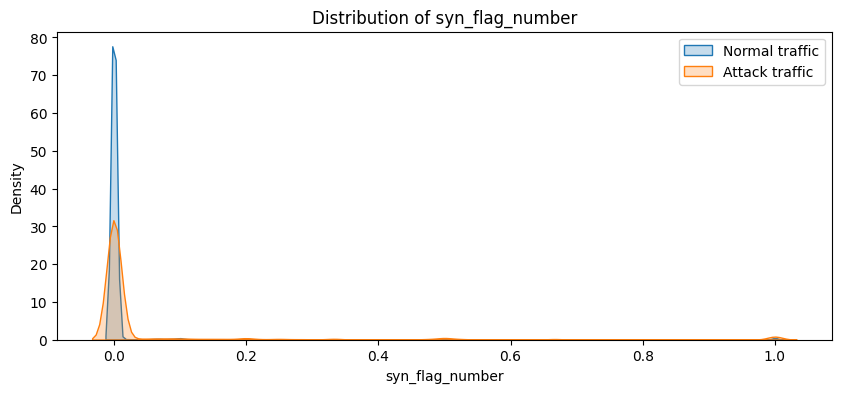

rst_flag_number
Normal:  1474280
Attack:  1411994


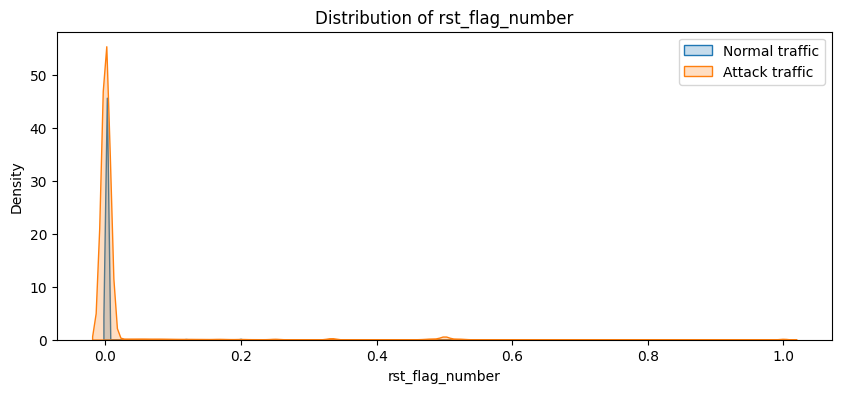

psh_flag_number
Normal:  1474280
Attack:  1411994


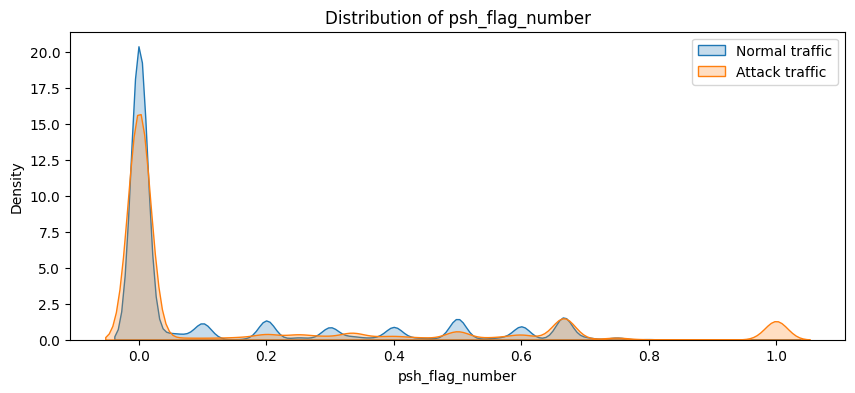

ack_flag_number
Normal:  1474280
Attack:  1411994


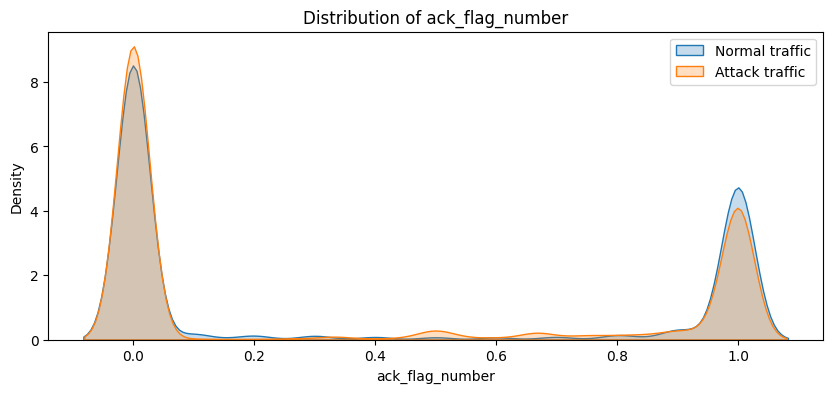

ece_flag_number
Normal:  1474280
Attack:  1411994


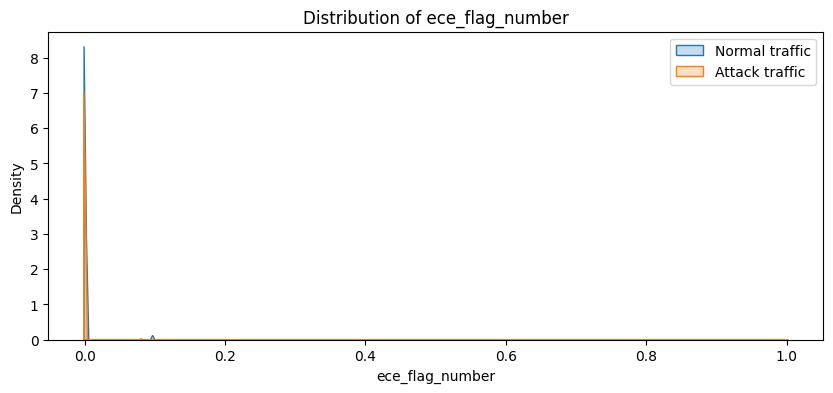

cwr_flag_number
Normal:  1474280
Attack:  1411994


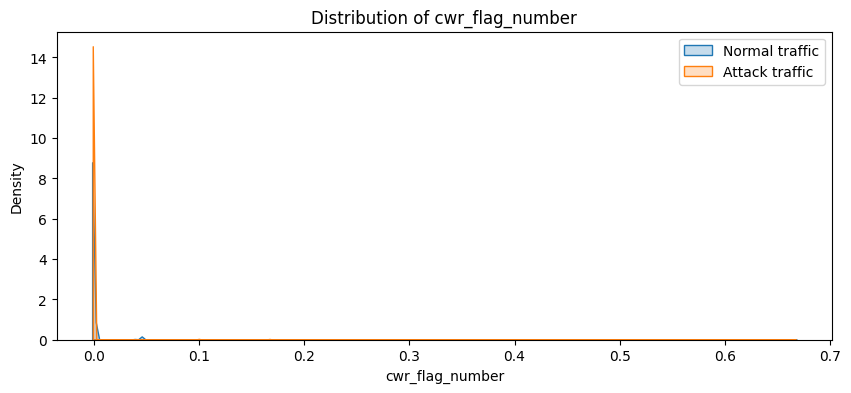

ack_count
Normal:  1474280
Attack:  1411994


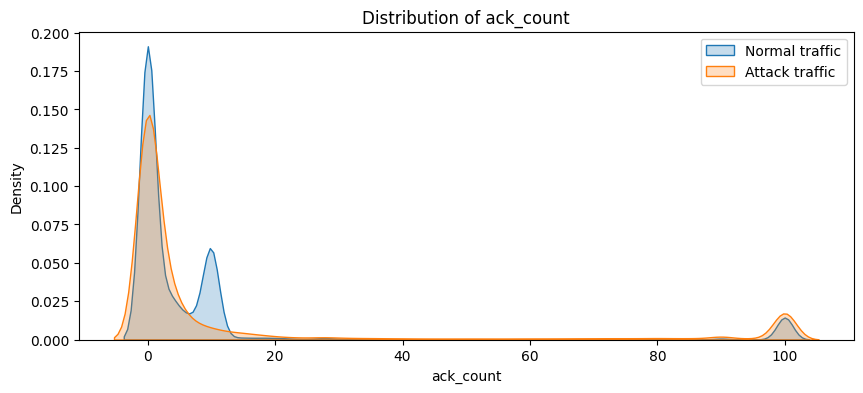

syn_count
Normal:  1474280
Attack:  1411994


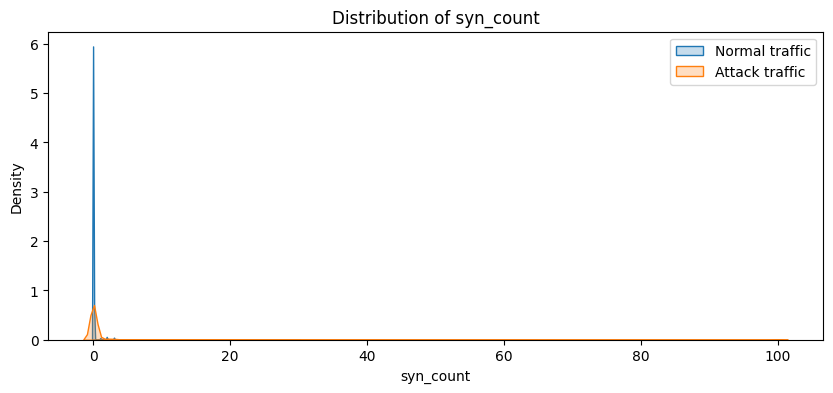

fin_count
Normal:  1474280
Attack:  1411994


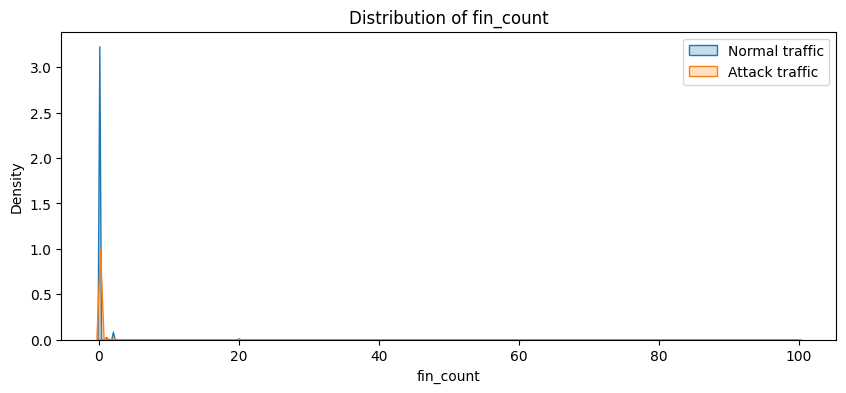

rst_count
Normal:  1474280
Attack:  1411994


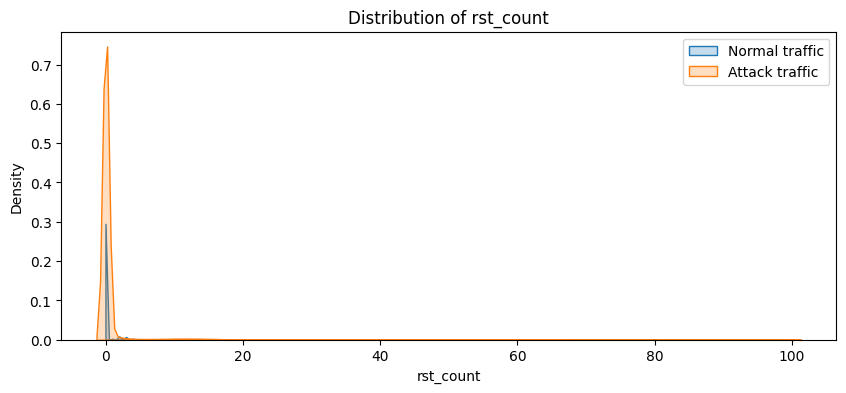

HTTP
Normal:  1474280
Attack:  1411994


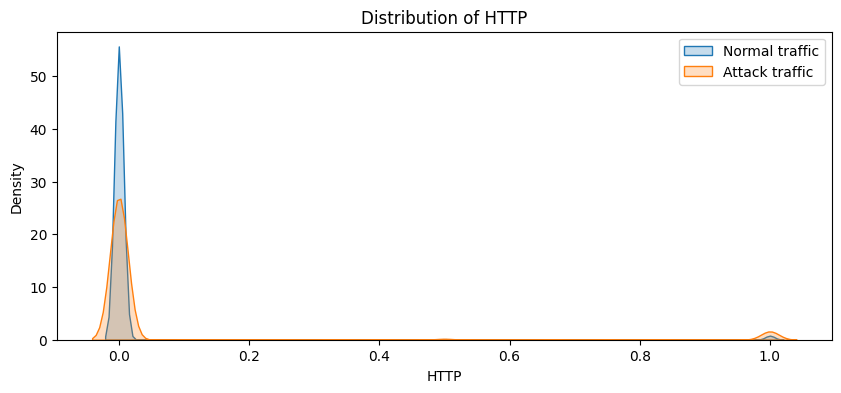

HTTPS
Normal:  1474280
Attack:  1411994


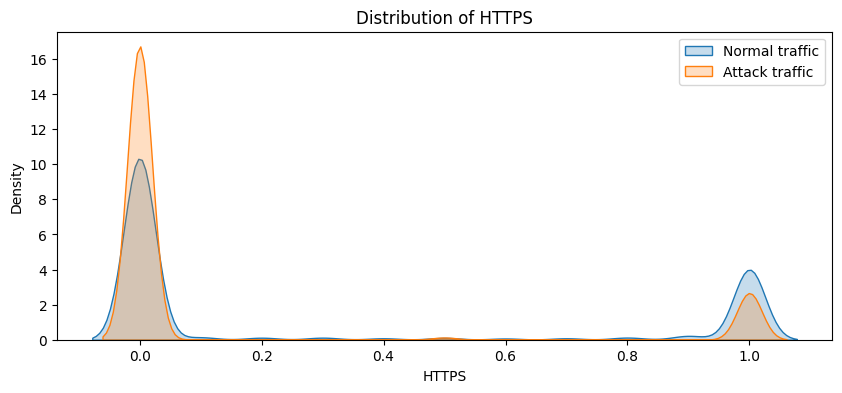

DNS
Normal:  1474280
Attack:  1411994


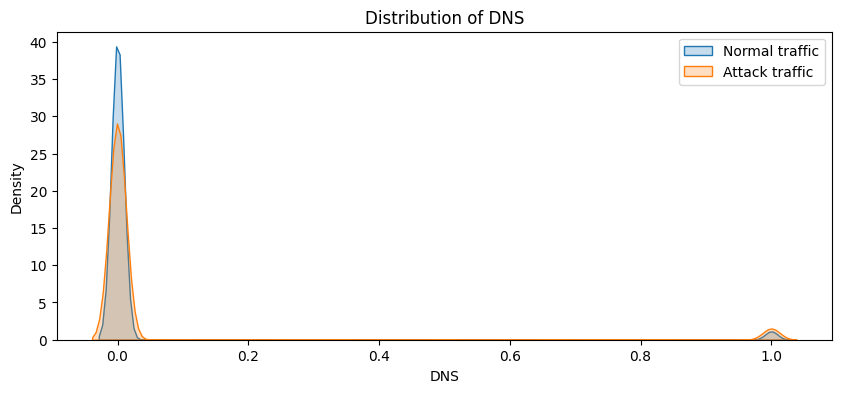

Telnet
Normal:  1474280
Attack:  1411994


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)


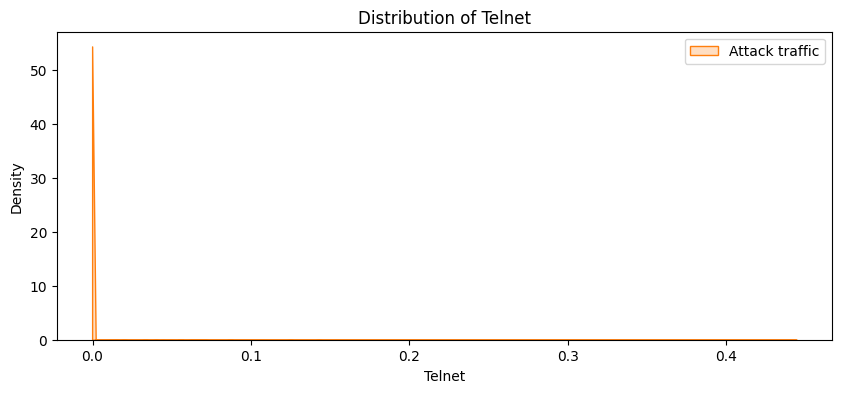

SMTP
Normal:  1474280
Attack:  1411994


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)


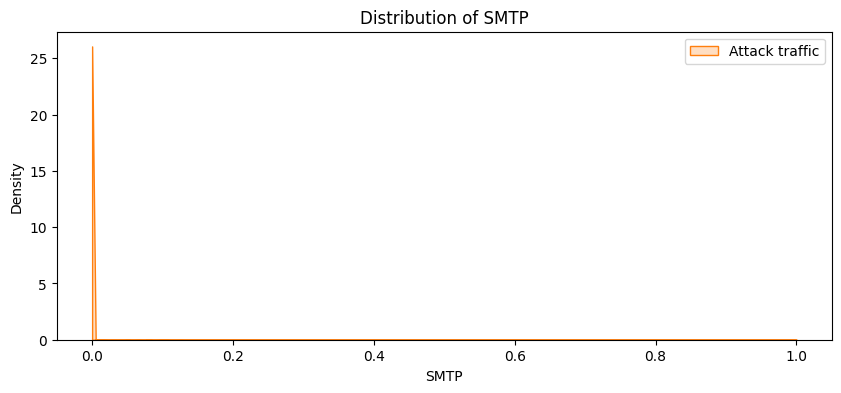

SSH
Normal:  1474280
Attack:  1411994


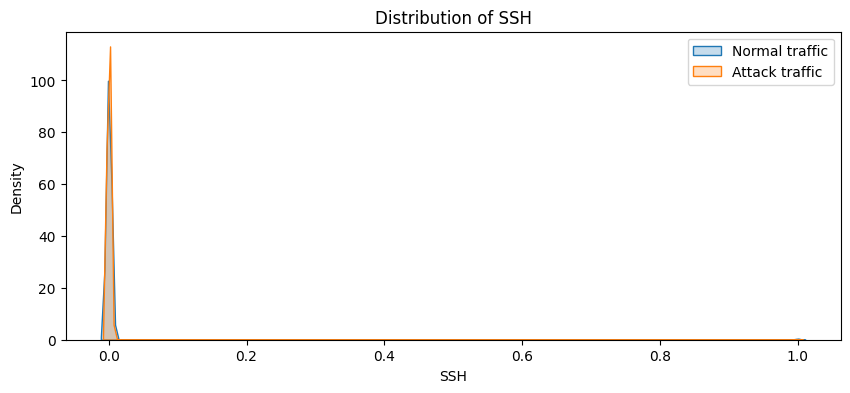

IRC
Normal:  1474280
Attack:  1411994


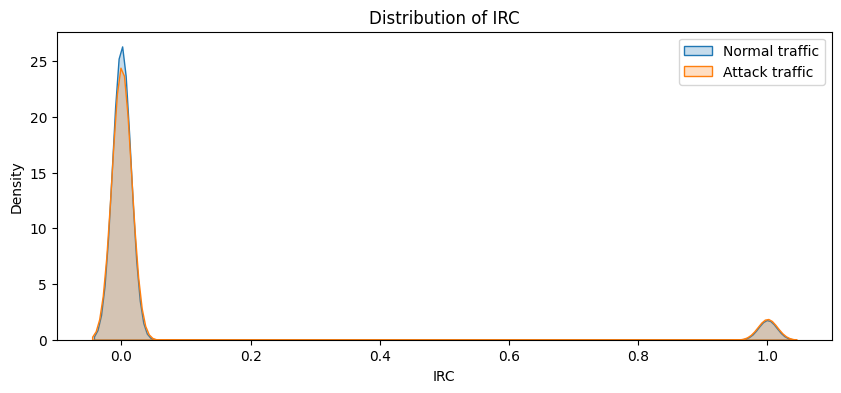

TCP
Normal:  1474280
Attack:  1411994


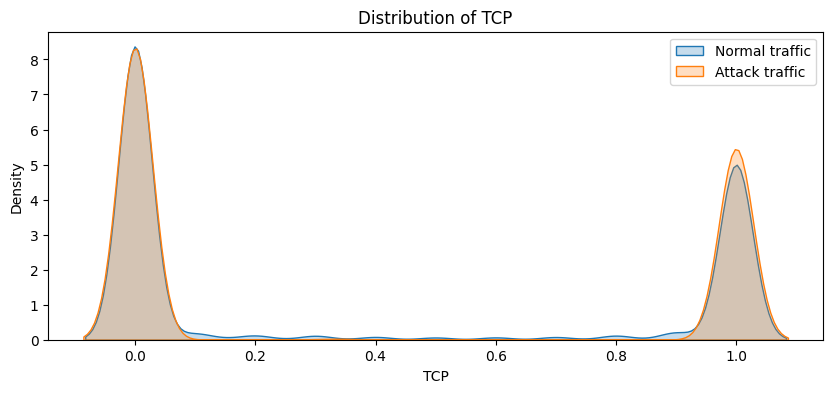

UDP
Normal:  1474280
Attack:  1411994


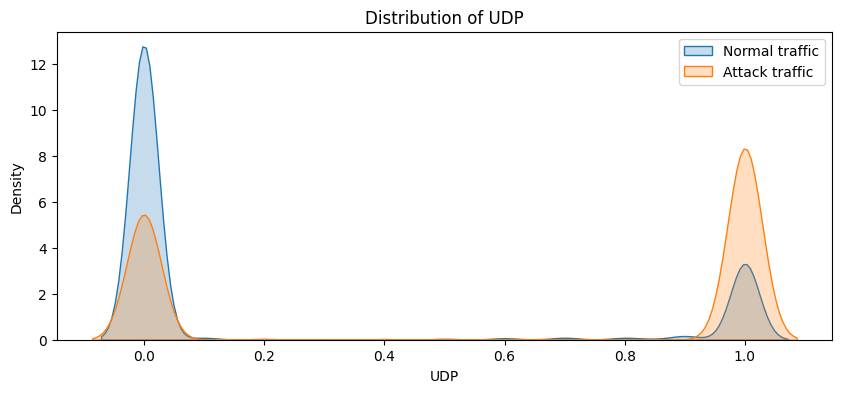

DHCP
Normal:  1474280
Attack:  1411994


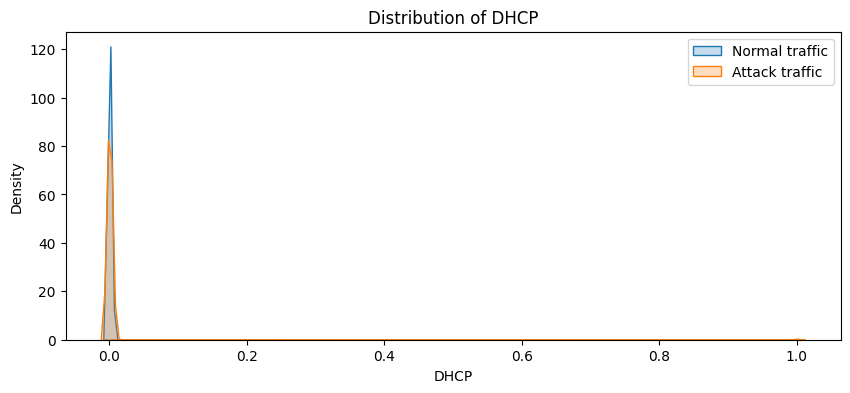

ARP
Normal:  1474280
Attack:  1411994


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)


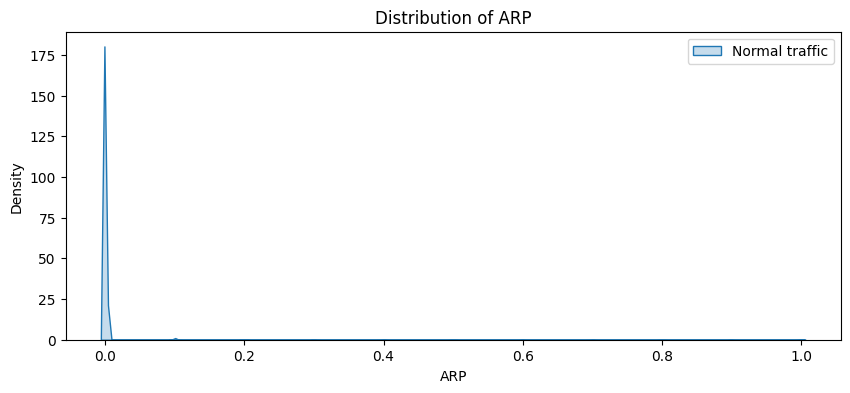

ICMP
Normal:  1474280
Attack:  1411994


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)


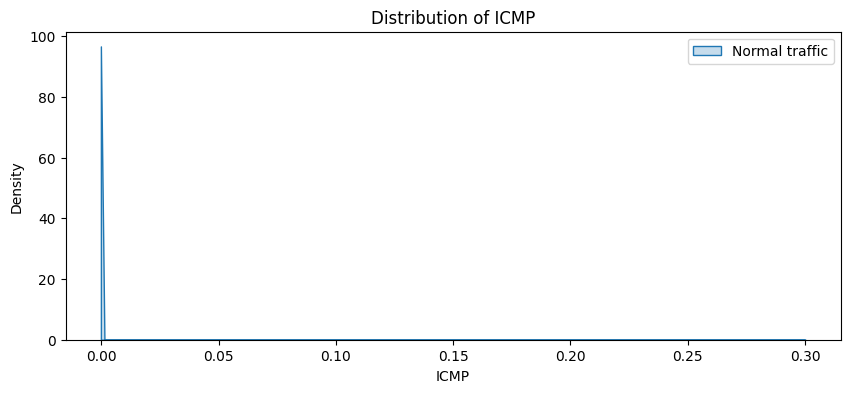

IGMP
Normal:  1474280
Attack:  1411994


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


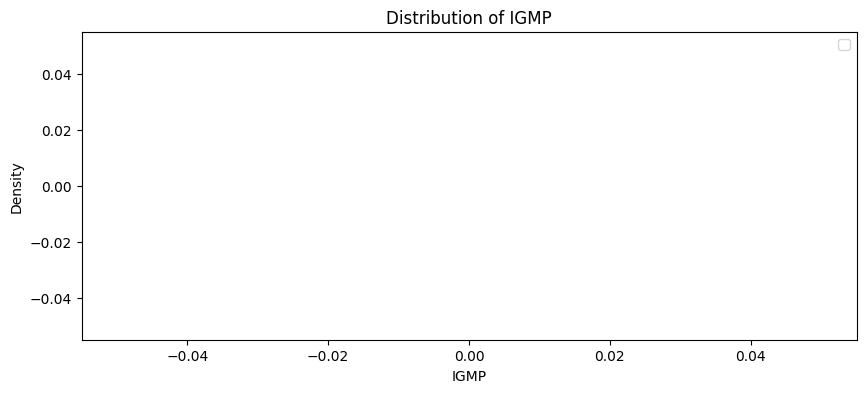

IPv
Normal:  1474280
Attack:  1411994


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)


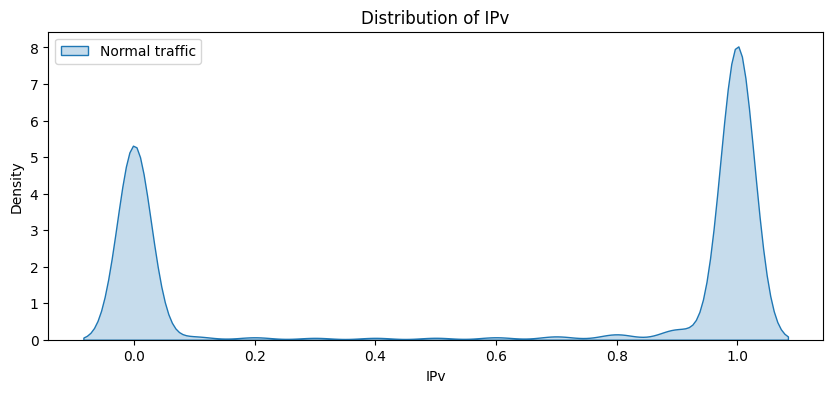

LLC
Normal:  1474280
Attack:  1411994


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\3656654131.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


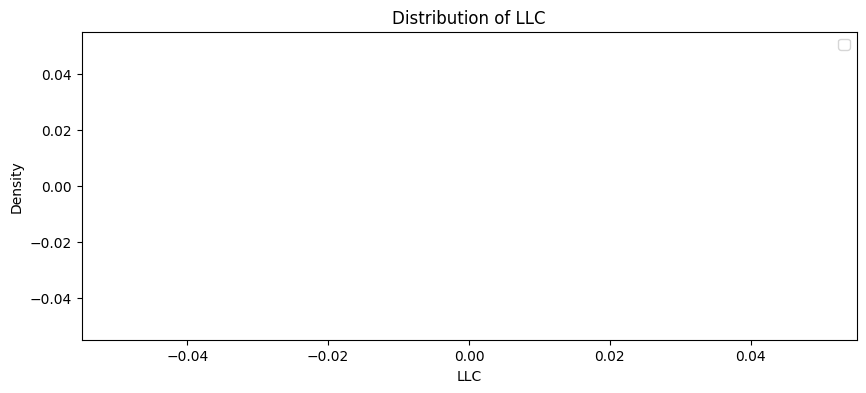

Tot sum
Normal:  1474280
Attack:  1411994


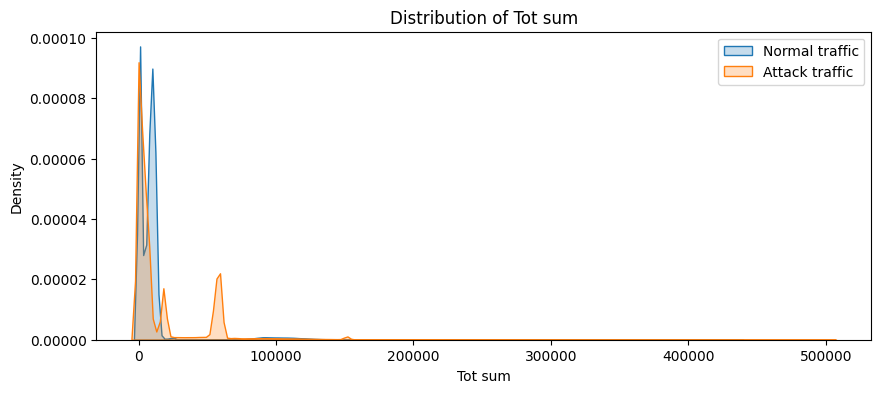

Min
Normal:  1474280
Attack:  1411994


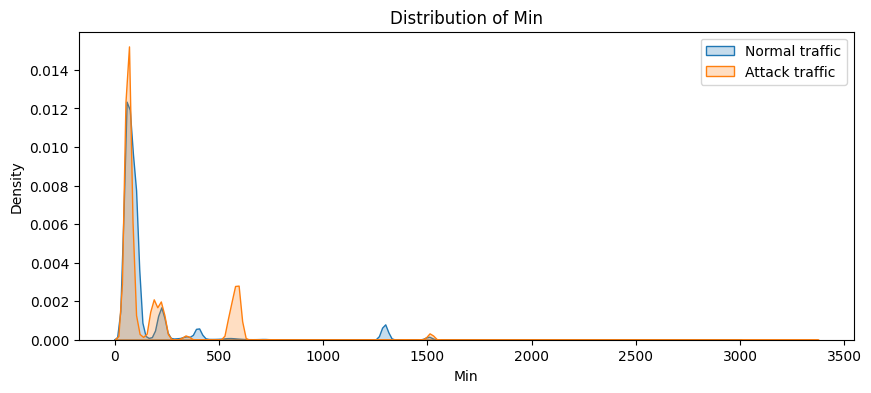

Max
Normal:  1474280
Attack:  1411994


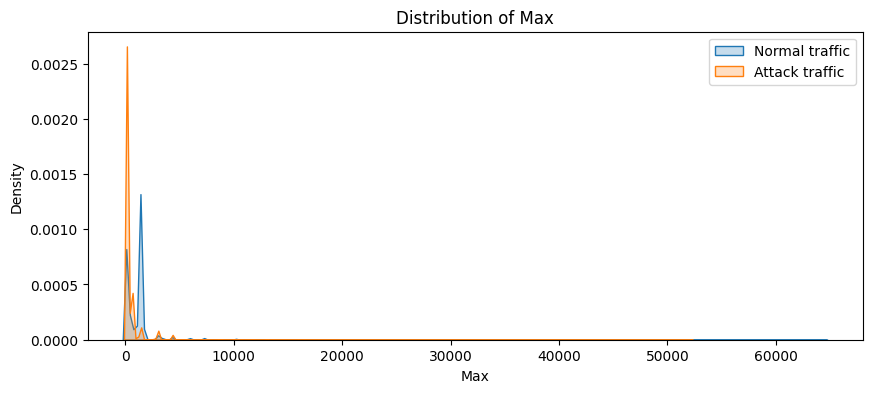

AVG
Normal:  1474280
Attack:  1411994


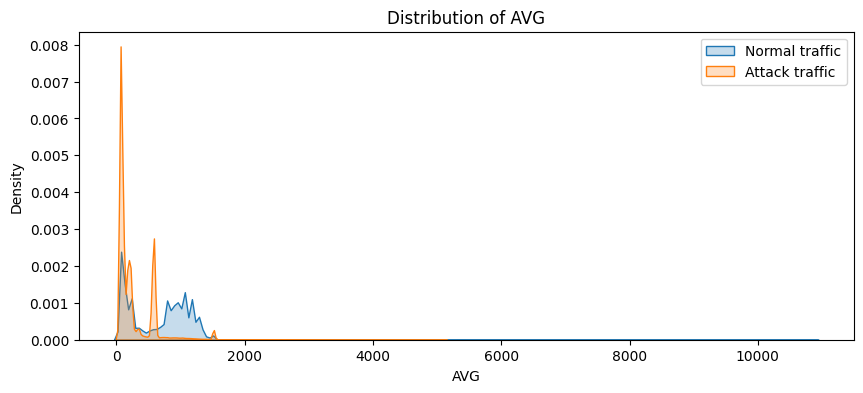

Std
Normal:  1474280
Attack:  1411994


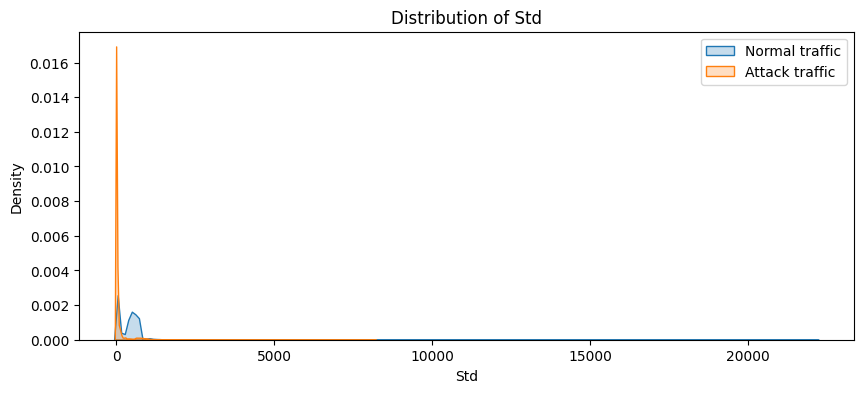

Tot size
Normal:  1474280
Attack:  1411994


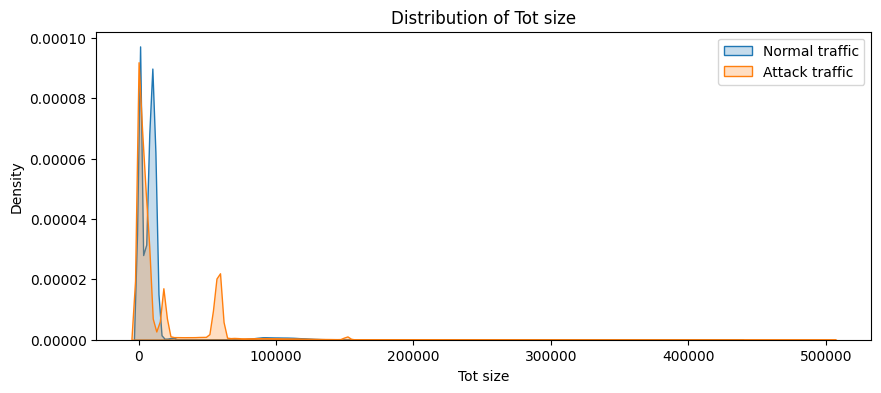

IAT
Normal:  1474280
Attack:  1411994


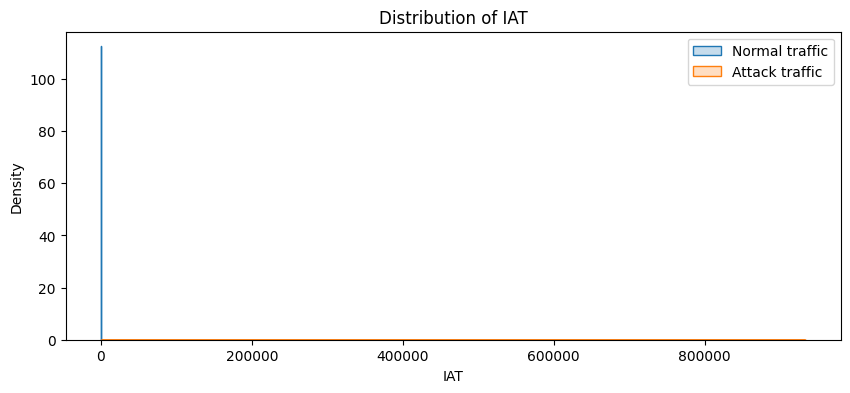

Number
Normal:  1474280
Attack:  1411994


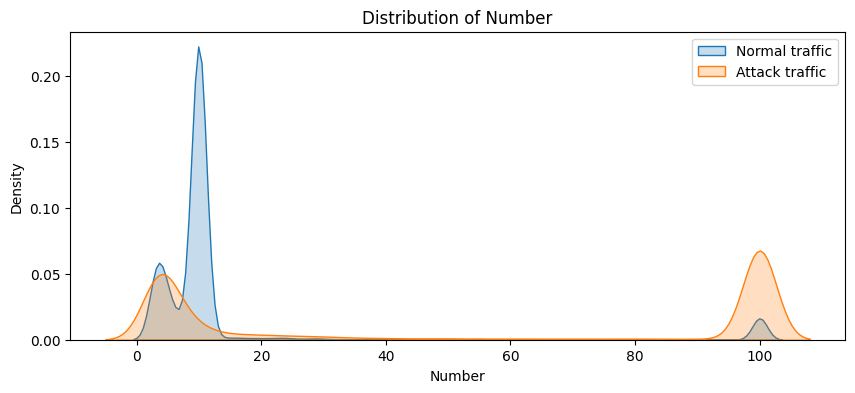

Variance
Normal:  1474280
Attack:  1411994


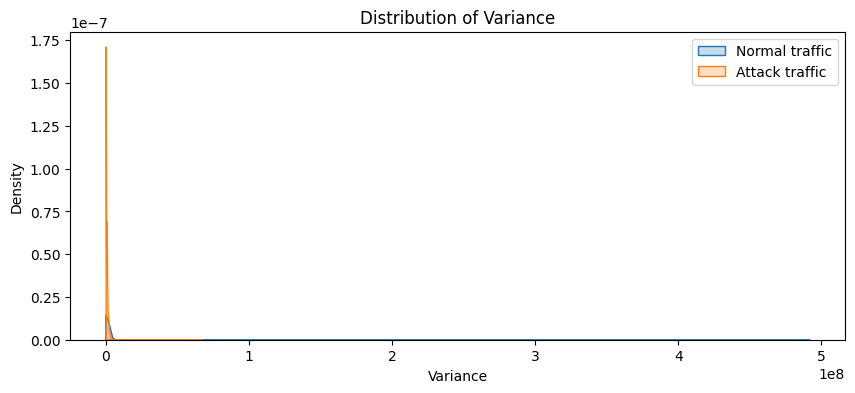

In [34]:
for col in common_columns.drop(['Label']):
    print(col)
    print("Normal: ", len(normal[col]))
    print("Attack: ", len(attack[col]))
    plt.figure(figsize=(10,4))
    sns.kdeplot(normal[col], label='Normal traffic', fill=True)
    sns.kdeplot(attack[col], label='Attack traffic', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

Grouping main categories into one category for binary classification

In [23]:
# attack = attack.drop(columns=[
#                     'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number',
#                     'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count',
#                     'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC',
#                     'IAT', 'Number'
#                 ])
# attack = attack.drop(columns=['ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'fin_count', 'rst_count', 
#                               'HTTPS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'IAT', 'Number'])
def limit(data):
    limits = round(data.shape[0]*90/100)
    return limits

attack_train = pd.concat([DDoS[0:limit(DDoS)], DoS[0:limit(DoS)], Mirai[0:limit(Mirai)], Web_based[0:limit(Web_based)], 
                          Spoofing[0:limit(Spoofing)], Recon[0:limit(Recon)], Brute_Force[0:limit(Brute_Force)]], axis=0, ignore_index=True)
attack_train = attack_train.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 
                              'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 
                              'rst_count', 'HTTP', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 
                              'DHCP', 'ARP', 'ICMP', 'IGMP', 'LLC'])
print("Training attack data: ",attack_train.shape)


attack_test = pd.concat([DDoS[limit(DDoS):DDoS.shape[0]], DoS[limit(DoS):DoS.shape[0]], Mirai[limit(Mirai):Mirai.shape[0]], 
                         Web_based[limit(Web_based):Web_based.shape[0]], Spoofing[limit(Spoofing):Spoofing.shape[0]], 
                         Recon[limit(Recon):Recon.shape[0]], Brute_Force[limit(Brute_Force):Brute_Force.shape[0]]], axis=0, ignore_index=True)
attack_test = attack_test.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 
                              'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 
                              'rst_count', 'HTTP', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 
                              'DHCP', 'ARP', 'ICMP', 'IGMP', 'LLC'])
print("Testing attack data: ",attack_test.shape)

Training attack data:  (1270795, 17)
Testing attack data:  (141199, 17)


In [24]:
# Grouping
Attack = ['DDoS', 'Web_based', 'DoS', 'Brute_Force', 'Recon', 'Spoofing', 'Mirai']

def classify_attacks(data):
    data['Label'] = data['Label'].replace(Attack, 1)
    # Ensure labels are integers
    data['Label'] = data['Label'].astype(int)
classify_attacks(attack_train)

In [25]:
# normal = normal.drop(columns=[
#                     'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number',
#                     'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count',
#                     'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC',
#                     'IAT', 'Number'
#                 ])
# normal = normal.drop(columns=['ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'fin_count', 'rst_count', 
#                               'HTTPS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'IAT', 'Number'])
normal = normal.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 
                              'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 
                              'rst_count', 'HTTP', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 
                              'DHCP', 'ARP', 'ICMP', 'IGMP', 'LLC'])
print("Normal data: ",normal.shape)
limits = round(normal.shape[0]*90/100)
print(limits)
normal_train = normal[0:limits] 
normal_test = normal[limits:normal.shape[0]]

Normal data:  (1474280, 17)
1326852


In [26]:
df = pd.concat([attack_train, normal_train], axis=0, ignore_index=True)
# df = normal_train.drop(columns=['Label'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.describe()
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2597647 entries, 0 to 2597646
Data columns (total 17 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Header_Length  float64
 1   Protocol Type  int64  
 2   Time_To_Live   float64
 3   Rate           float64
 4   ack_count      int64  
 5   HTTPS          float64
 6   IPv            float64
 7   Tot sum        int64  
 8   Min            int64  
 9   Max            int64  
 10  AVG            float64
 11  Std            float64
 12  Tot size       int64  
 13  IAT            float64
 14  Number         int64  
 15  Variance       float64
 16  Label          int64  
dtypes: float64(9), int64(8)
memory usage: 336.9 MB


In [ ]:
df['Label'].value_counts()

These are the sub-cat that underperforming according to the Random Forest model (Also drop the BENIGN since we use our own BENIGN)

In [ ]:
delete_cat = ['DDOS-RSTFINFLOOD', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'RECON-OSSCAN', 'RECON-PORTSCAN', 'BENIGN']

df = df[~df['Label'].isin(delete_cat)].reset_index(drop=True)

Grouping sub-categories into one category for binary classification

In [ ]:
# Grouping
Attack = ['DDOS-ACK_FRAGMENTATION',     
        'DDOS-UDP_FLOOD',       
        'DDOS-SLOWLORIS',               
        'DDOS-ICMP_FLOOD',     
        'DDOS-PSHACK_FLOOD',        
        'DDOS-HTTP_FLOOD',              
        'DDOS-UDP_FRAGMENTATION',         
        'DDOS-ICMP_FRAGMENTATION',
        'DDOS-RSTFINFLOOD', 
        'DDOS-SYNONYMOUSIP_FLOOD', 
        'DDOS-SYN_FLOOD', 
        'DDOS-TCP_FLOOD',
        'DOS-UDP_FLOOD',       
        'DOS-HTTP_FLOOD',
        'DOS-SYN_FLOOD', 
        'DOS-TCP_FLOOD',
        'MITM-ARPSPOOFING',     
        'DNS_SPOOFING',
        'DICTIONARYBRUTEFORCE',
        'RECON-HOSTDISCOVERY',                
        'RECON-PINGSWEEP',
        'RECON-OSSCAN', 
        'RECON-PORTSCAN',       
        'VULNERABILITYSCAN',
        'SQLINJECTION',        
        'BROWSERHIJACKING',         
        'COMMANDINJECTION',       
        'XSS',         
        'BACKDOOR_MALWARE',          
        'UPLOADING_ATTACK',
        'MIRAI-GREETH_FLOOD',     
        'MIRAI-UDPPLAIN',     
        'MIRAI-GREIP_FLOOD']

def classify_attacks(data):
    data['Label'].replace(Attack,1,inplace=True)
classify_attacks(df)

In [ ]:
df = pd.concat([df, normal_train], axis=0, ignore_index=True)
# df = normal_train.drop(columns=['Label'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.describe()
df.head()
df.info()

In [ ]:
df['Label'].value_counts()

Grouping sub-category into main categories for multiclass classification

In [ ]:
# Grouping
DDoS = ['DDOS-ACK_FRAGMENTATION',     
        'DDOS-UDP_FLOOD',       
        'DDOS-SLOWLORIS',               
        'DDOS-ICMP_FLOOD',        
        'DDOS-RSTFINFLOOD',    
        'DDOS-PSHACK_FLOOD',        
        'DDOS-HTTP_FLOOD',              
        'DDOS-UDP_FRAGMENTATION',     
        'DDOS-TCP_FLOOD',  
        'DDOS-SYN_FLOOD',        
        'DDOS-SYNONYMOUSIP_FLOOD',    
        'DDOS-ICMP_FRAGMENTATION']

DoS = ['DOS-UDP_FLOOD',    
       'DOS-TCP_FLOOD',    
       'DOS-SYN_FLOOD',    
       'DOS-HTTP_FLOOD']

Spoofing = ['MITM-ARPSPOOFING',     
            'DNS_SPOOFING']

Brute_Force = ['DICTIONARYBRUTEFORCE']

Recon = ['RECON-HOSTDISCOVERY', 
         'RECON-OSSCAN',     
         'RECON-PORTSCAN',               
         'RECON-PINGSWEEP',         
         'VULNERABILITYSCAN']

Web_based = ['SQLINJECTION',        
             'BROWSERHIJACKING',         
             'COMMANDINJECTION',       
             'XSS',         
             'BACKDOOR_MALWARE',          
             'UPLOADING_ATTACK']

Mirai = ['MIRAI-GREETH_FLOOD',     
         'MIRAI-UDPPLAIN',     
         'MIRAI-GREIP_FLOOD']



def classify_attacks(data):
    data['Label'].replace(DDoS,'DDoS',inplace=True)
    data['Label'].replace(DoS,'DoS',inplace=True)
    data['Label'].replace(Spoofing,'Spoofing',inplace=True)
    data['Label'].replace(Brute_Force,'Brute_Force',inplace=True)
    data['Label'].replace(Recon,'Recon',inplace=True)
    data['Label'].replace(Web_based,'Web_based',inplace=True)
    data['Label'].replace(Mirai,'Mirai',inplace=True)
classify_attacks(df)

In [ ]:
# Train set preprocessing
df.drop_duplicates(keep='first', inplace = True)
df.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
df.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
df.reset_index(drop=True, inplace=True)

Export csv that contain only 1 label

In [ ]:
category_counts = df["Label"].value_counts()
category_names = category_counts.index.tolist()

for cat in category_names:
    csv_by_label = df[df['Label'] == cat]
    csv_by_label.to_csv('../2nd_Label_CSV/{}.csv'.format(cat), index=False)

In [70]:
columns_name = df.drop(columns=['Label']).columns

In [ ]:
X_train_val = df

In [27]:
# Create train data
X_train_val = df.drop(columns=['Label'])
Y_train_val = df['Label']

In [ ]:
print(X_train_val.shape)
print(Y_train_val.shape)

In [28]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
0    1326852
1    1270795
Name: count, dtype: int64


In [29]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy='all') # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded


X_train_val, Y_train_val = undersample.fit_resample(X_train_val, Y_train_val)

In [ ]:
# Over sampling
sm = SMOTE()
X_train_val, Y_train_val = sm.fit_resample(X_train_val, Y_train_val)

print(Y_train_val.shape)
print(X_train_val.shape)

In [30]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
0    1270795
1    1270795
Name: count, dtype: int64


In [ ]:
X_train_val

In [31]:
# scaler = StandardScaler()
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_val)
#X_test_scaled = scaler.fit_transform(X_test)

In [32]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_scaled, Y_train_val, test_size=0.2, random_state=33, shuffle=True)

In [ ]:
X_train

#### Neural Network

In [ ]:
_features = X_train.shape[1]

In [ ]:
nn_model = Sequential([
    Input(shape=(_features,)),

    # CNN layer structure
    # Convolution1D(256, 6, activation='relu'),
    # layers.BatchNormalization(),
    # MaxPooling1D(2),
    # Convolution1D(128, 6, activation='relu'),
    # layers.BatchNormalization(),
    # UpSampling1D(3),
    # Convolution1D(256, 6, activation='relu'),
    # Flatten(), # Maybe when we don't use lstm
    
    # LSTM layer structure
    # LSTM(512, return_sequences=False),
    # Dense(256, activation='relu'),
    
    # FNN layer structure
    Dense(256, activation='relu'), # Already have a Dense above
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Classification layer
    Dense(1, activation='sigmoid'),  # Softmax for multiclass, Sigmoid for binary, both use as output layer. Also, binary classification only have one output
])

In [ ]:
nn_model.summary()

In [ ]:
opt = optimizers.Adam(learning_rate=0.0001)
nn_model.compile(loss='binary_crossentropy',optimizer=opt, metrics=['accuracy'])
early_stop_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=5)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                  patience=3, min_lr=0.0001)

In [ ]:
start_fit = time.time()
history = nn_model.fit(X_train, Y_train,
                              batch_size=128,
                              epochs=10,
                              verbose=True,
                              validation_data=(X_val, Y_val))    

end_fit = time.time()
fit_time = end_fit - start_fit
print("fit time: {:.2f} seconds".format(fit_time))  

In [ ]:
test_set = pd.concat([attack_test, normal_test], axis=0, ignore_index=True)
# test_set = normal_train.drop(columns=['Label'])
test_set = test_set.sample(frac=1, random_state=42).reset_index(drop=True)

test_set.drop_duplicates(keep='first', inplace = True)
test_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
test_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
test_set.reset_index(drop=True, inplace=True)

# Create test data
X_test = test_set.drop(columns=['Label'])
Y_test = test_set['Label']

y_pred_nn = nn_model.predict(X_test)
# y_pred_nn will be probabilities in [0,1]
y_pred_labels = (y_pred_nn > 0.5).astype(int).flatten()
print(classification_report(Y_test, y_pred_labels))

In [ ]:
# Test set preprocessing
normal_test.drop_duplicates(keep='first', inplace = True)
normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal_test.reset_index(drop=True, inplace=True)

X_sample = normal_test.drop(columns=['Label'])
Y_sample = normal_test['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

score = 0
total = 1000

for i in range(total):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[-i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = nn_model.predict(sample)[0]
    pred_labels = (pred > 0.5).astype(int).flatten()
    actual = Y_sample.iloc[-i]

    if pred_labels == actual:
        score += 1
        
    print(f"Sample {-i}: Predicted = {pred_labels}, Actual = {actual}")

print("Percentage: ", (score/total)*100)

In [ ]:
attack_sample = DDoS.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC', 'IAT', 'Number'])
# attack_sample = attack_test
# Test set preprocessing
attack_sample.drop_duplicates(keep='first', inplace = True)
attack_sample.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_sample.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_sample.reset_index(drop=True, inplace=True)

X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

score = 0
total = 500

for i in range(total):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[-i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = nn_model.predict(sample)[0]
    pred_labels = (pred > 0.5).astype(int).flatten()
    actual = Y_sample.iloc[-i]

    if pred_labels == actual:
        score += 1
        
    print(f"Sample {-i}: Predicted = {pred_labels}, Actual = {actual}")

print("Percentage: ", (score/total)*100)

#### Random Forest

In [41]:
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=15,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=20,   # Reduce splits on small nodes
                                    min_samples_leaf=20,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=20, min_samples_split=20,
                       n_jobs=-1, random_state=42)

In [43]:
y_pred_frst = frst_model.predict(X_val)
print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91    253645
           1       0.89      0.95      0.92    254673

    accuracy                           0.92    508318
   macro avg       0.92      0.92      0.91    508318
weighted avg       0.92      0.92      0.91    508318



In [44]:
test_set = pd.concat([attack_test, normal_test], axis=0, ignore_index=True)
# test_set = normal_train.drop(columns=['Label'])
test_set = test_set.sample(frac=1, random_state=42).reset_index(drop=True)

test_set.drop_duplicates(keep='first', inplace = True)
test_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
test_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
test_set.reset_index(drop=True, inplace=True)

# Create test data
X_test = df.drop(columns=['Label'])
Y_test = df['Label']

y_pred_frst = frst_model.predict(X_test)
print(classification_report(Y_test, y_pred_frst))

c:\Users\ADMIN\anaconda3\envs\thinh\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.42      0.59   1326852
           1       0.62      1.00      0.77   1270795

    accuracy                           0.70   2597647
   macro avg       0.81      0.71      0.68   2597647
weighted avg       0.82      0.70      0.68   2597647



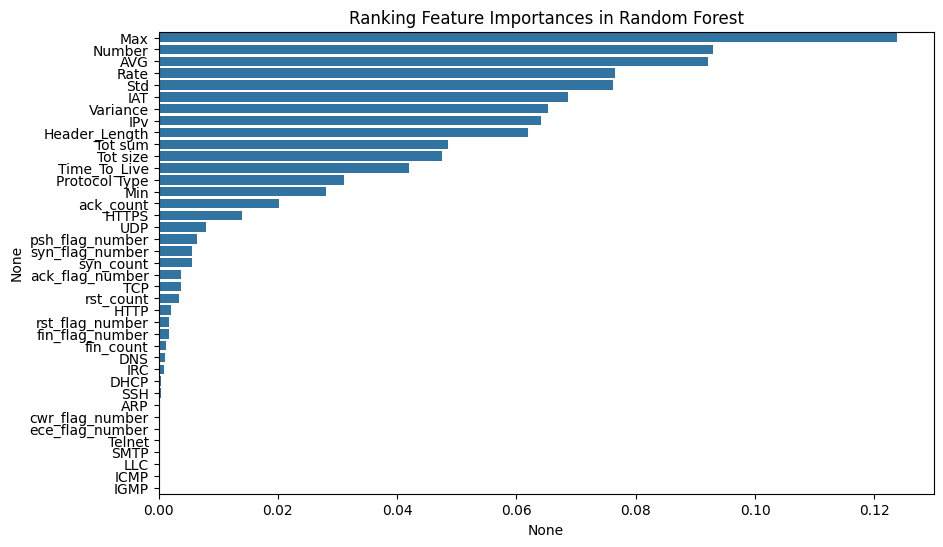

In [72]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Ranking Feature Importances in Random Forest")
plt.show()

In [51]:
# Save the model
with open('../Models/CIC_models/new_frst_model_1st_stage.pkl', 'wb') as f:
    pickle.dump(frst_model, f)

In [ ]:
# Load the model
with open('../Models/CIC_models/new_frst_model_1st_stage.pkl', 'rb') as f:
    frst_model = pickle.load(f)

In [45]:
# Test set preprocessing
normal_test.drop_duplicates(keep='first', inplace = True)
normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal_test.reset_index(drop=True, inplace=True)

X_sample = normal_test.drop(columns=['Label'])
Y_sample = normal_test['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

score = 0
total = 1000

for i in range(total):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[-i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[-i]

    if pred == actual:
        score += 1
        
    print(f"Sample {-i}: Predicted = {pred}, Actual = {actual}")

print("Percentage: ", (score/total)*100)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3736\2491100435.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normal_test.drop_duplicates(keep='first', inplace = True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3736\2491100435.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3736\2491100435.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org

Sample 0: Predicted = 0, Actual = 0
Sample -1: Predicted = 0, Actual = 0
Sample -2: Predicted = 1, Actual = 0
Sample -3: Predicted = 0, Actual = 0
Sample -4: Predicted = 0, Actual = 0
Sample -5: Predicted = 0, Actual = 0
Sample -6: Predicted = 1, Actual = 0
Sample -7: Predicted = 1, Actual = 0
Sample -8: Predicted = 0, Actual = 0
Sample -9: Predicted = 0, Actual = 0
Sample -10: Predicted = 0, Actual = 0
Sample -11: Predicted = 0, Actual = 0
Sample -12: Predicted = 0, Actual = 0
Sample -13: Predicted = 0, Actual = 0
Sample -14: Predicted = 0, Actual = 0
Sample -15: Predicted = 1, Actual = 0
Sample -16: Predicted = 0, Actual = 0
Sample -17: Predicted = 0, Actual = 0
Sample -18: Predicted = 0, Actual = 0
Sample -19: Predicted = 0, Actual = 0
Sample -20: Predicted = 1, Actual = 0
Sample -21: Predicted = 0, Actual = 0
Sample -22: Predicted = 0, Actual = 0
Sample -23: Predicted = 0, Actual = 0
Sample -24: Predicted = 1, Actual = 0
Sample -25: Predicted = 0, Actual = 0
Sample -26: Predicted =

In [50]:
def limit(data):
    limits = round(data.shape[0]*90/100)
    return limits

attack_sample = Spoofing[limit(Spoofing):Spoofing.shape[0]].drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 
                              'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 
                              'rst_count', 'HTTP', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 
                              'DHCP', 'ARP', 'ICMP', 'IGMP', 'LLC'])
Attack = ['DDoS', 'Web_based', 'DoS', 'Brute_Force', 'Recon', 'Spoofing', 'Mirai']
def classify_attacks(data):
    data['Label'] = data['Label'].replace(Attack, 1)
    # Ensure labels are integers
    data['Label'] = data['Label'].astype(int)
classify_attacks(attack_sample)
# attack_sample = attack_test

# attack_sample = pd.read_csv('C:/Users/ADMIN/Downloads/threat_logs.csv', encoding='cp1252', index_col=None, header=0).drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC', 'IAT', 'Number'])
# Test set preprocessing
attack_sample.drop_duplicates(keep='first', inplace = True)
attack_sample.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_sample.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_sample.reset_index(drop=True, inplace=True)

# X_sample = attack_sample
X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

score = 0
total = 1000

for i in range(total):
    # sample = X_test.iloc[[len(attack_sample) - i]]  # Must be 2D
    sample = X_sample_scaled[- i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[- i]

    if pred == actual:
        score += 1
        
    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")
    # print(f"Sample {i}: Predicted = {pred}")

print("Percentage: ", (score/total)*100)

Sample 0: Predicted = 0, Actual = 1
Sample 1: Predicted = 0, Actual = 1
Sample 2: Predicted = 0, Actual = 1
Sample 3: Predicted = 0, Actual = 1
Sample 4: Predicted = 0, Actual = 1
Sample 5: Predicted = 1, Actual = 1
Sample 6: Predicted = 1, Actual = 1
Sample 7: Predicted = 0, Actual = 1
Sample 8: Predicted = 0, Actual = 1
Sample 9: Predicted = 0, Actual = 1
Sample 10: Predicted = 0, Actual = 1
Sample 11: Predicted = 1, Actual = 1
Sample 12: Predicted = 1, Actual = 1
Sample 13: Predicted = 0, Actual = 1
Sample 14: Predicted = 0, Actual = 1
Sample 15: Predicted = 0, Actual = 1
Sample 16: Predicted = 0, Actual = 1
Sample 17: Predicted = 0, Actual = 1
Sample 18: Predicted = 0, Actual = 1
Sample 19: Predicted = 0, Actual = 1
Sample 20: Predicted = 0, Actual = 1
Sample 21: Predicted = 1, Actual = 1
Sample 22: Predicted = 0, Actual = 1
Sample 23: Predicted = 0, Actual = 1
Sample 24: Predicted = 0, Actual = 1
Sample 25: Predicted = 0, Actual = 1
Sample 26: Predicted = 0, Actual = 1
Sample 27: 

### 2nd stage model (multiclass classification)

In [86]:
X_dist_test = attack.drop(columns=['Label'])
Y_dist_test = attack['Label']

Header_Length
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


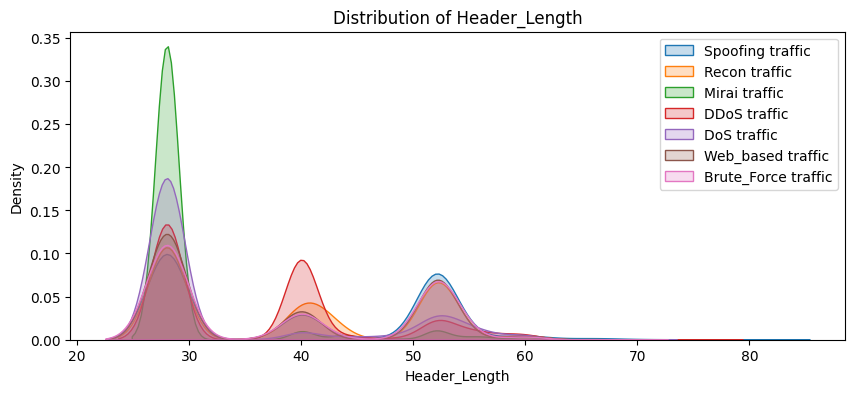

Protocol Type
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


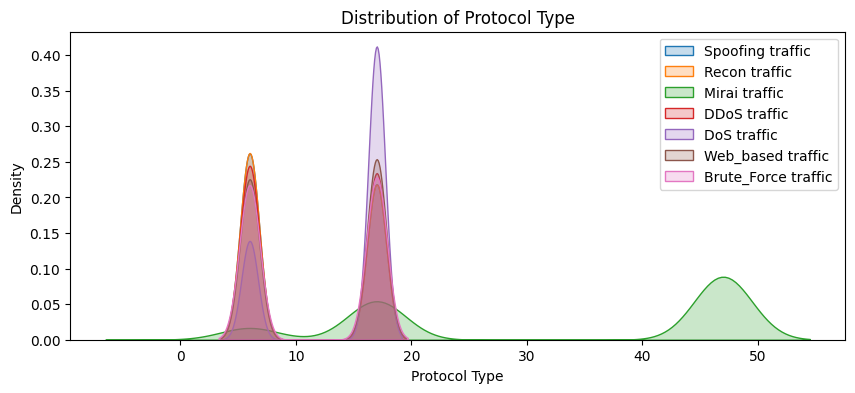

Time_To_Live
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


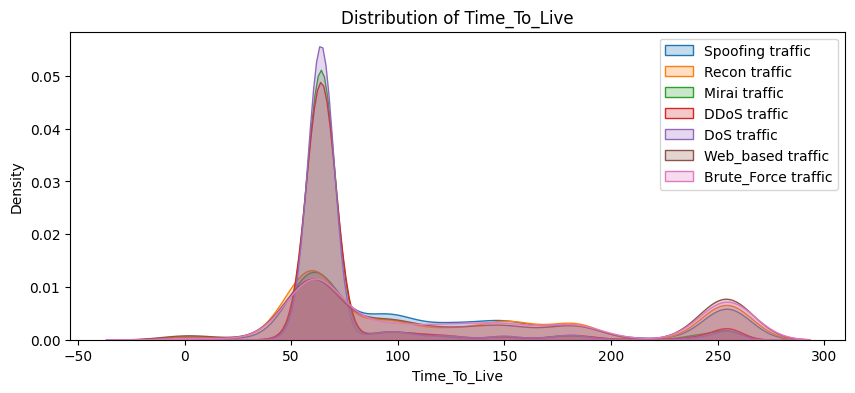

Rate
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


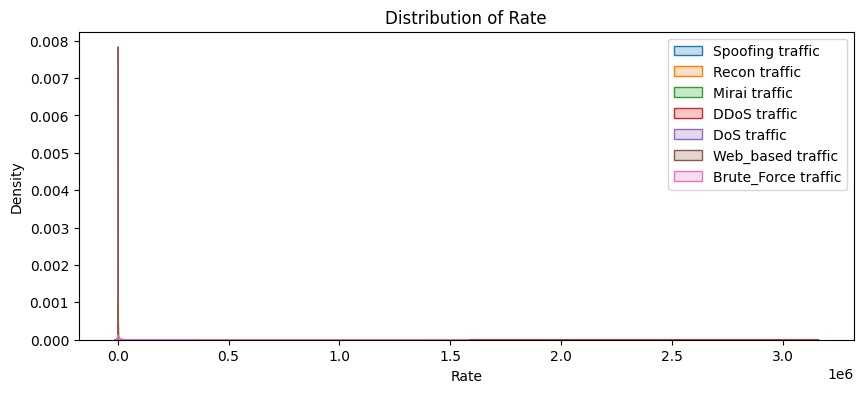

fin_flag_number
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


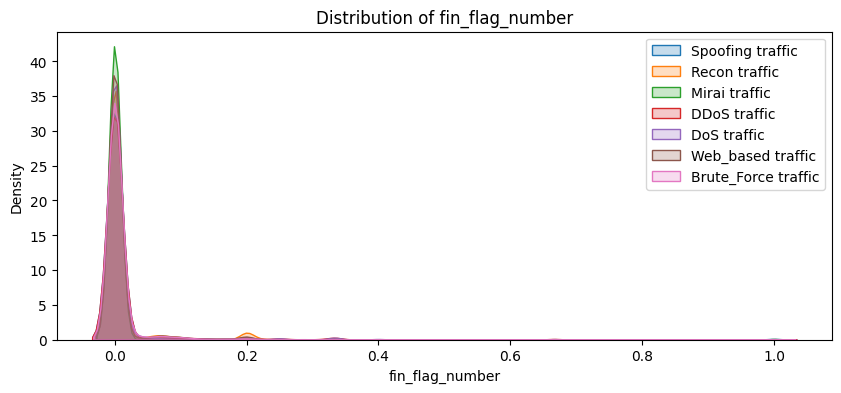

syn_flag_number
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


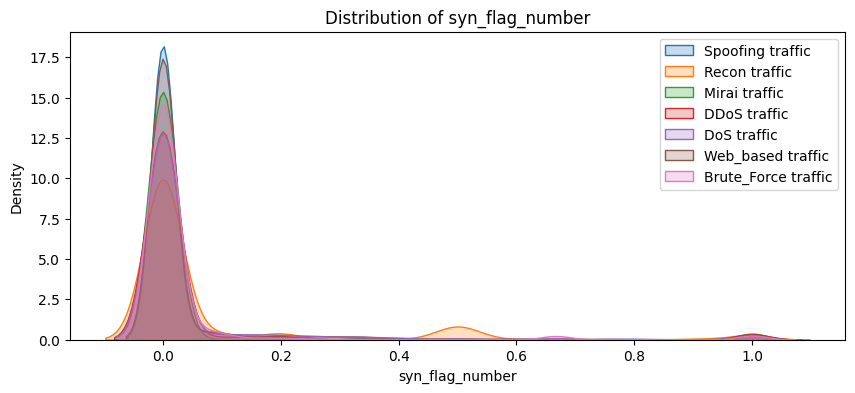

rst_flag_number
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


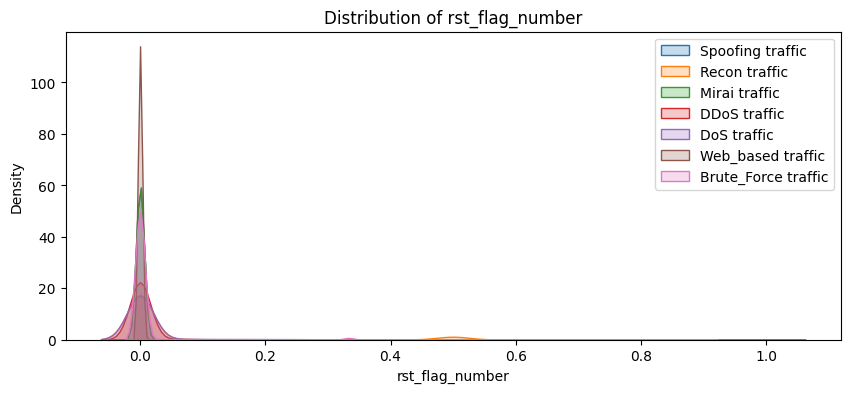

psh_flag_number
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


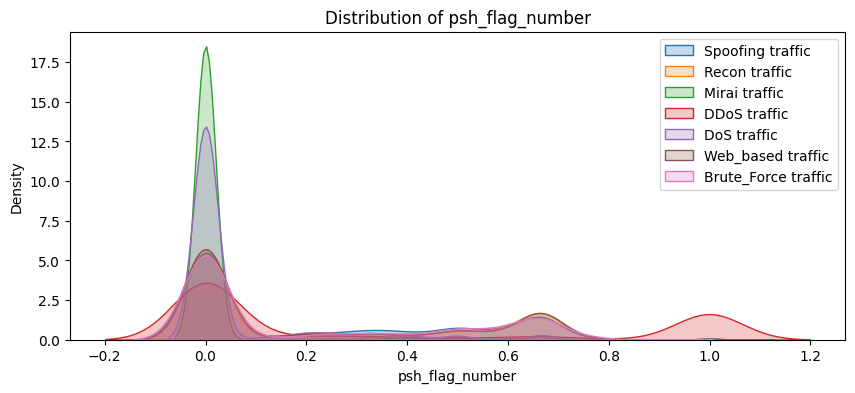

ack_flag_number
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


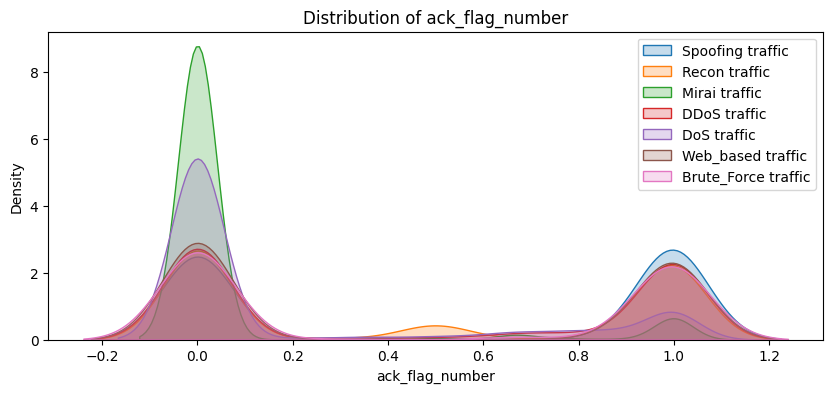

ece_flag_number
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)


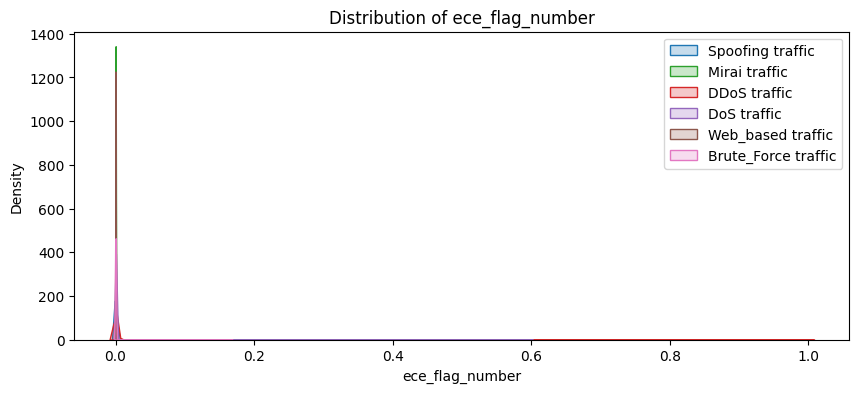

cwr_flag_number
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)


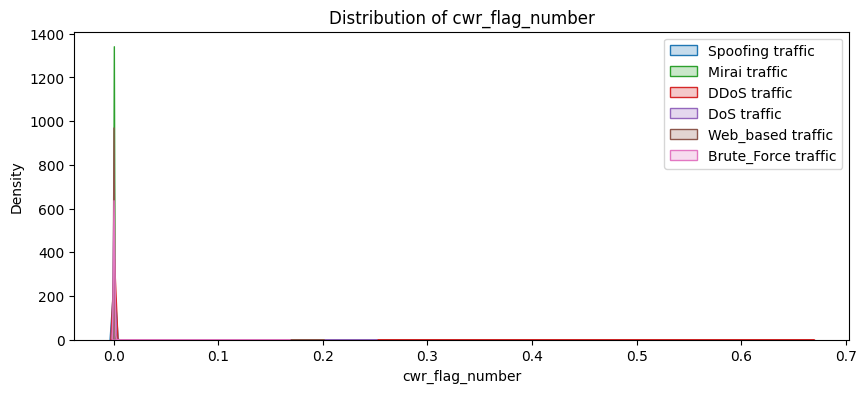

ack_count
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


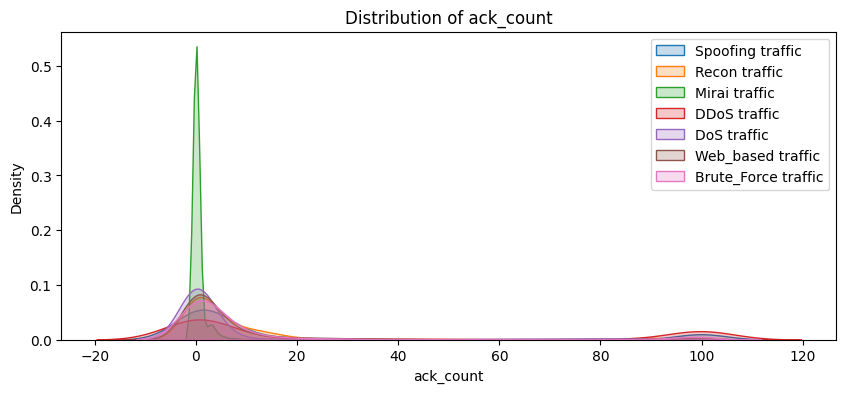

syn_count
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


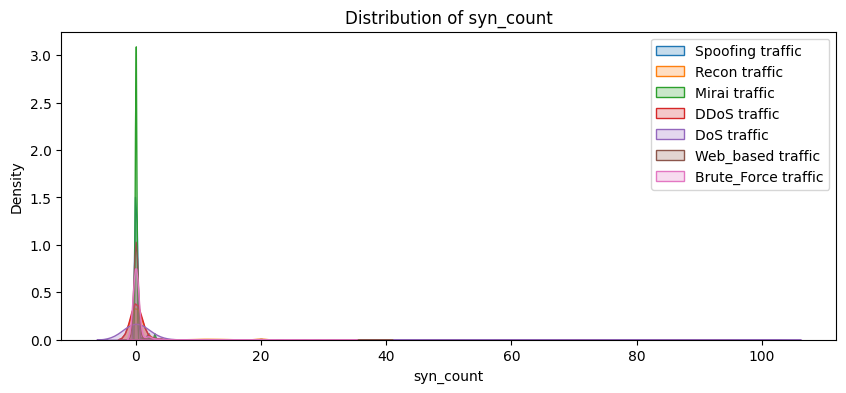

fin_count
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


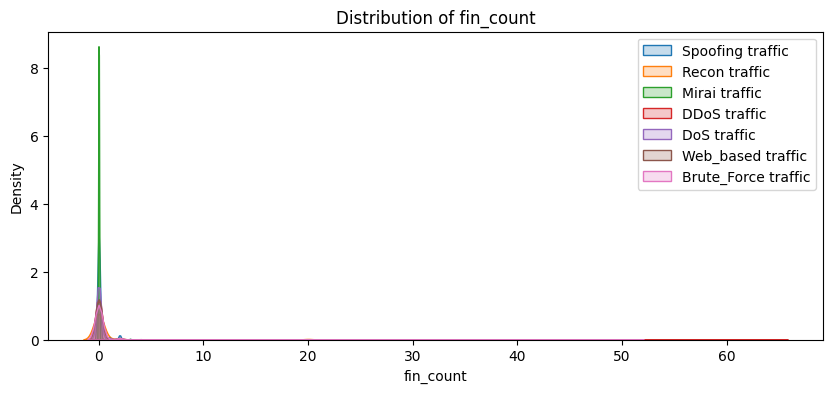

rst_count
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


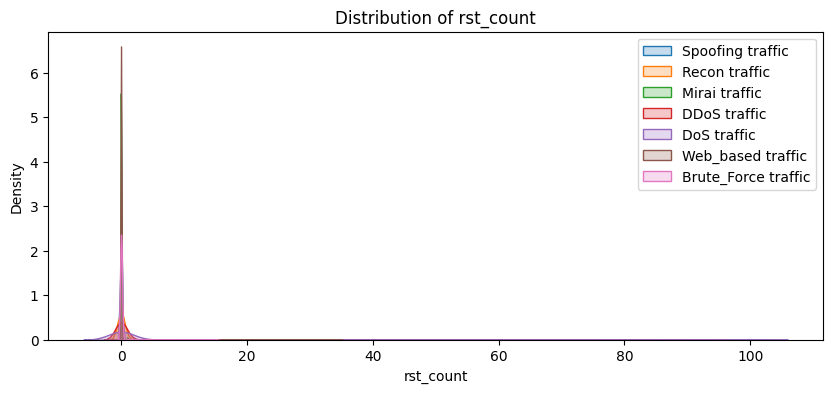

HTTP
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


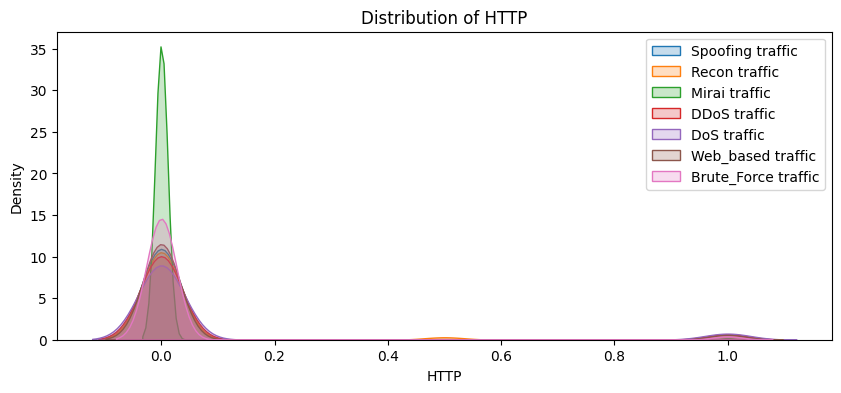

HTTPS
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


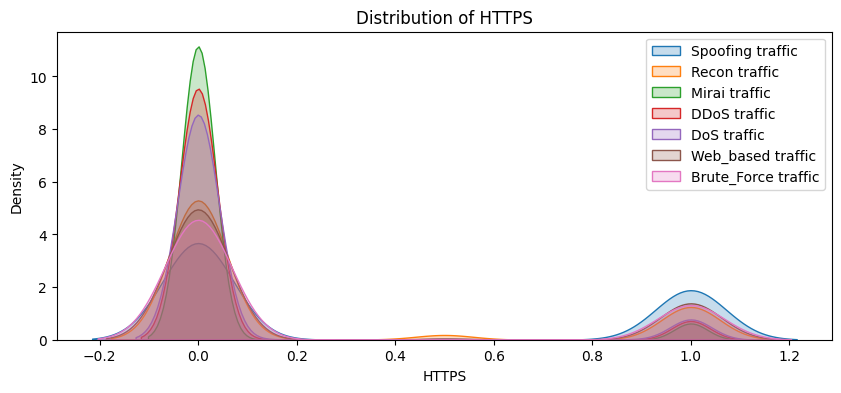

DNS
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


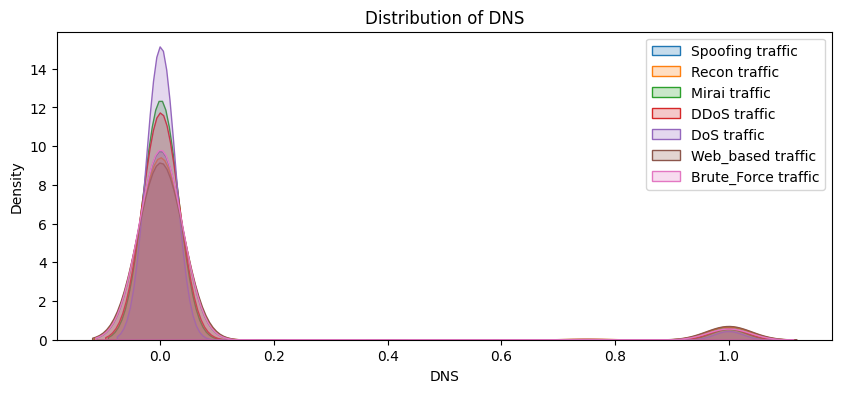

Telnet
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Web_based[:12522][col], label='Web_based traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:17: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Brute_Force[:12522][col], label='Brute_Force traffic', fill=True)


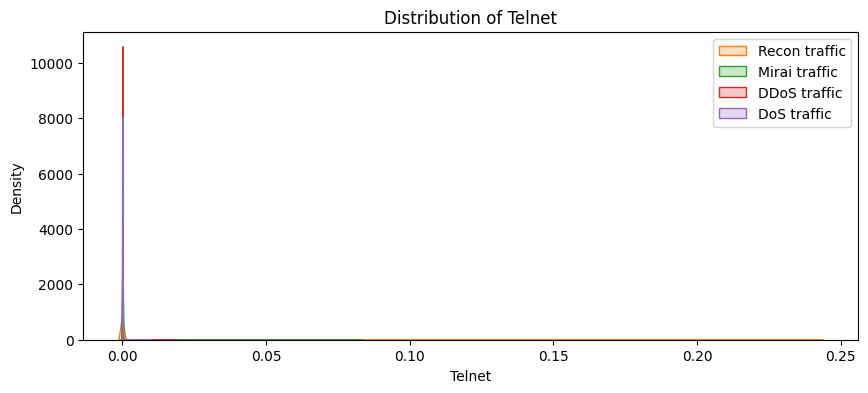

SMTP
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Web_based[:12522][col], label='Web_based traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:17: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Brute_Force[:12522][col], label='Brute_Force traffic', fill=True)


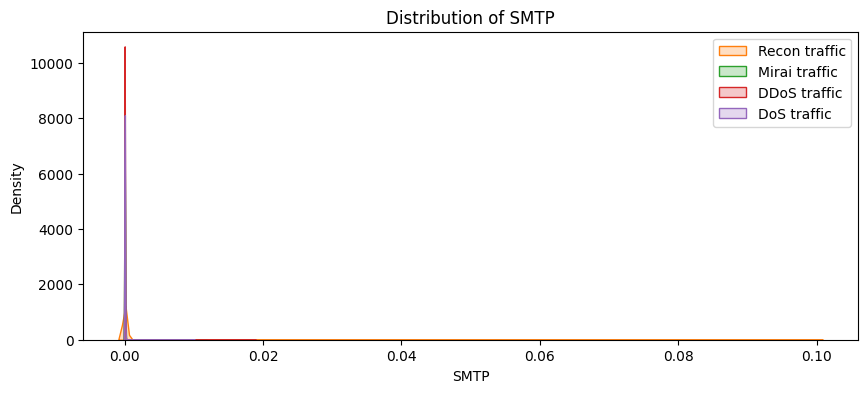

SSH
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)


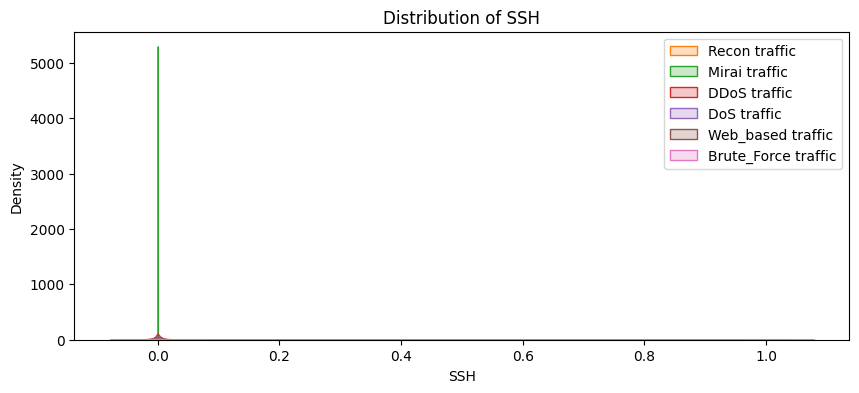

IRC
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


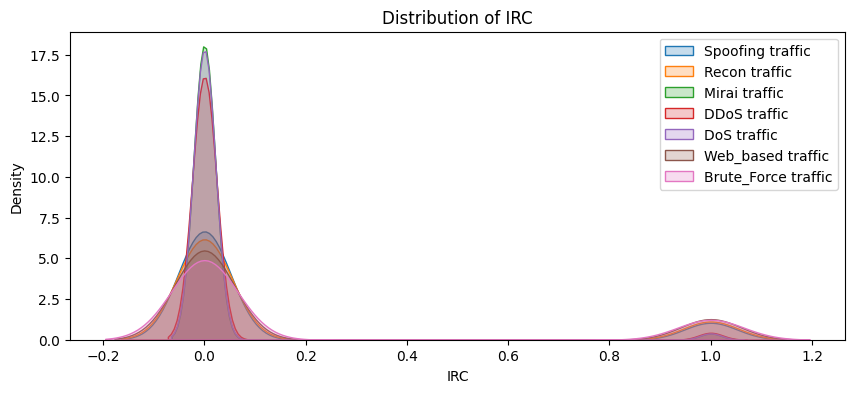

TCP
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


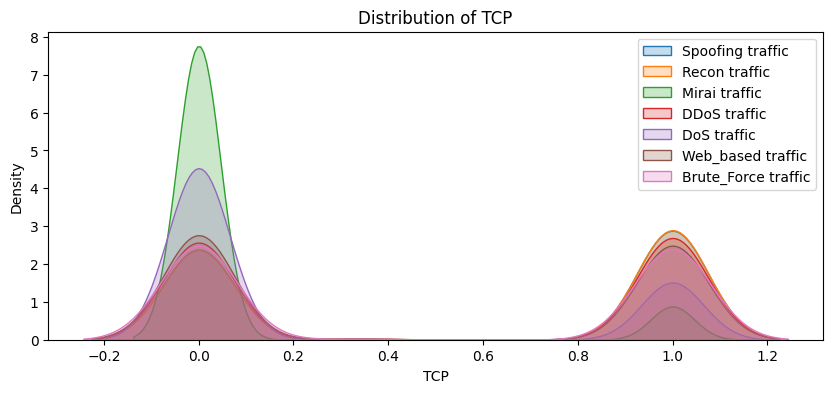

UDP
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


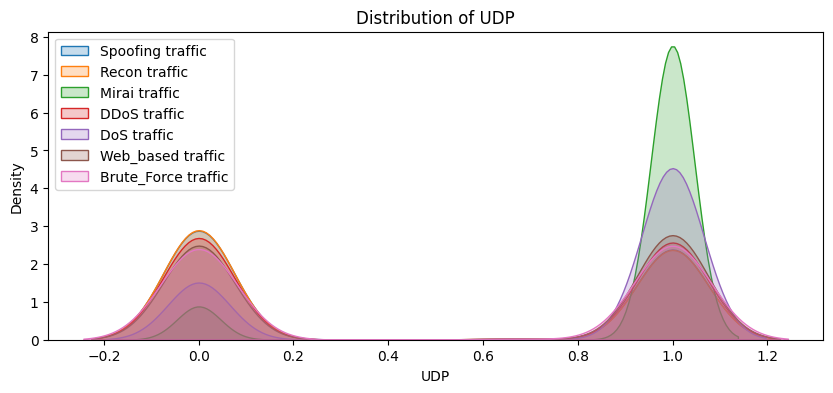

DHCP
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


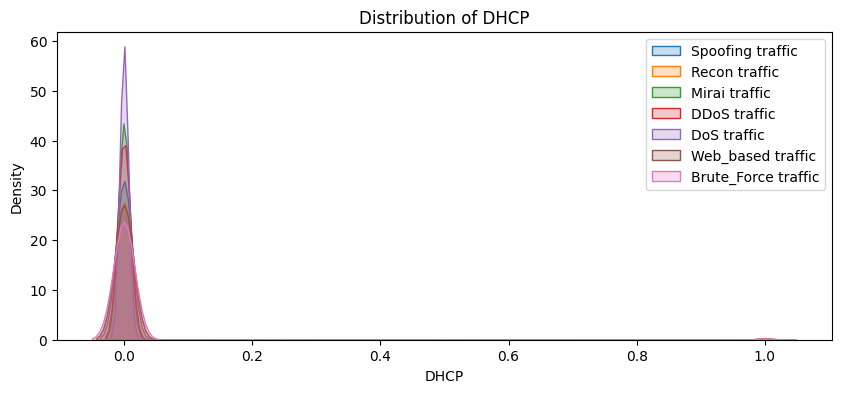

ARP
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Mirai[:12522][col], label='Mirai traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(DDoS[:12522][col], label='DDoS traffic',

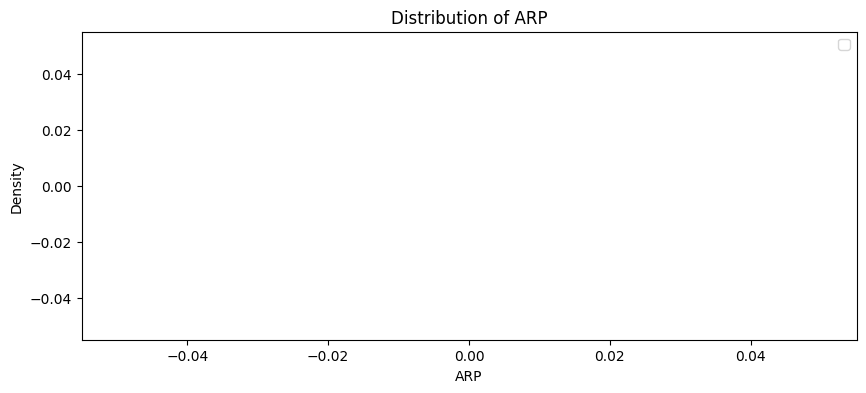

ICMP
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Mirai[:12522][col], label='Mirai traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(DDoS[:12522][col], label='DDoS traffic',

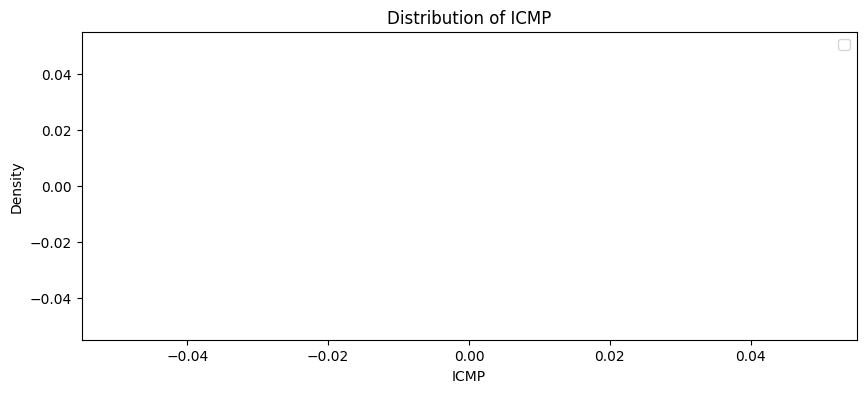

IGMP
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Mirai[:12522][col], label='Mirai traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(DDoS[:12522][col], label='DDoS traffic',

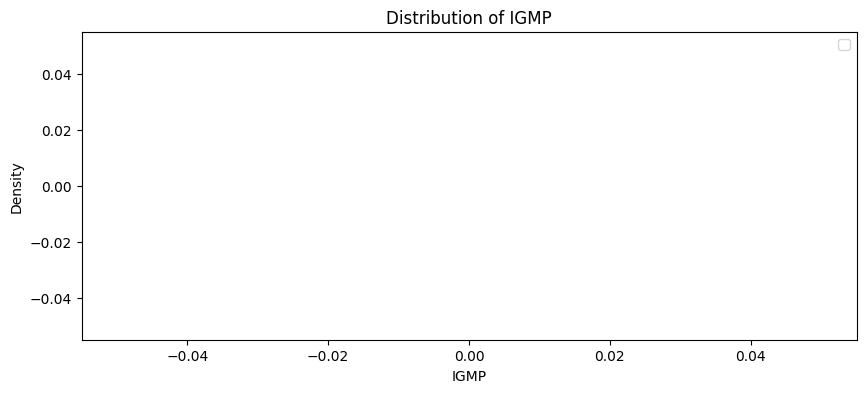

IPv
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Mirai[:12522][col], label='Mirai traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(DDoS[:12522][col], label='DDoS traffic',

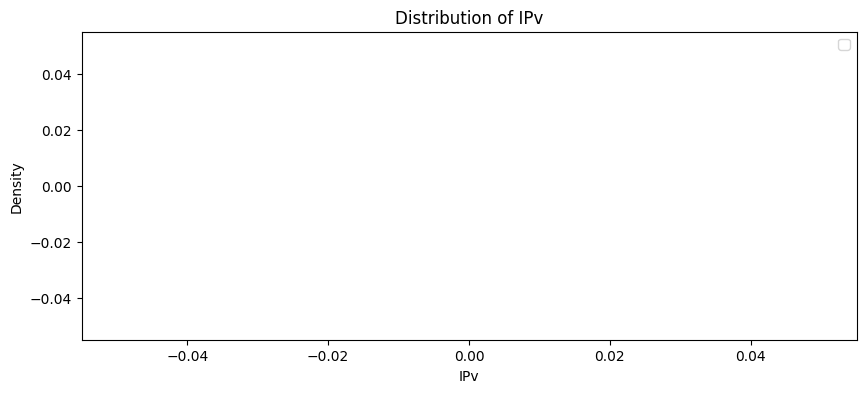

LLC
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Mirai[:12522][col], label='Mirai traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36092\1245586183.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(DDoS[:12522][col], label='DDoS traffic',

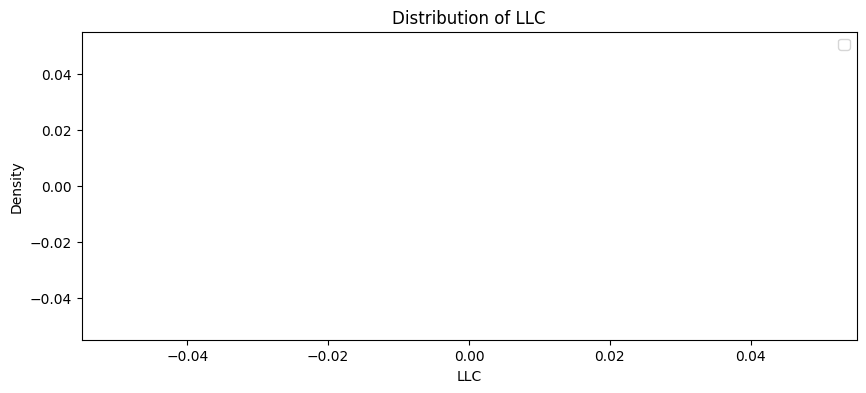

Tot sum
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


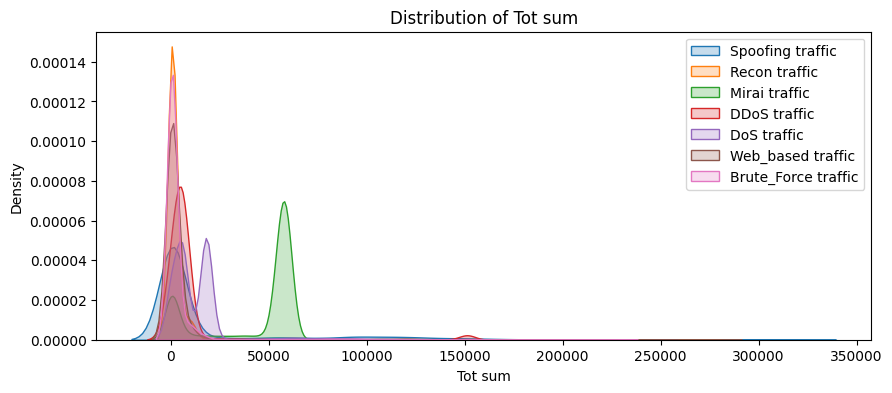

Min
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


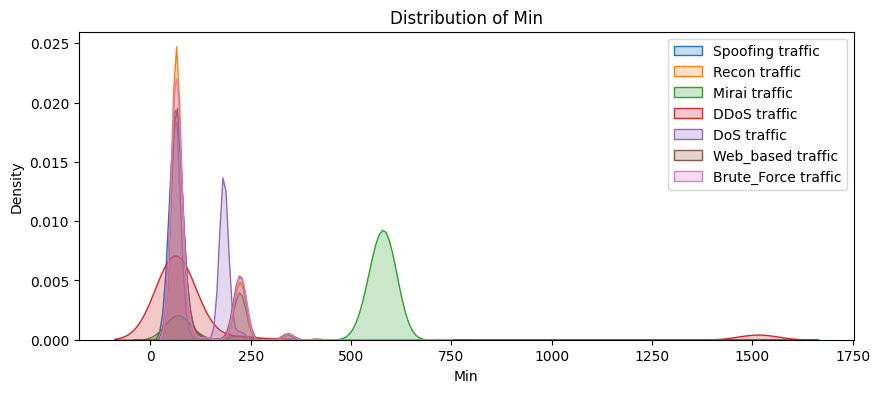

Max
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


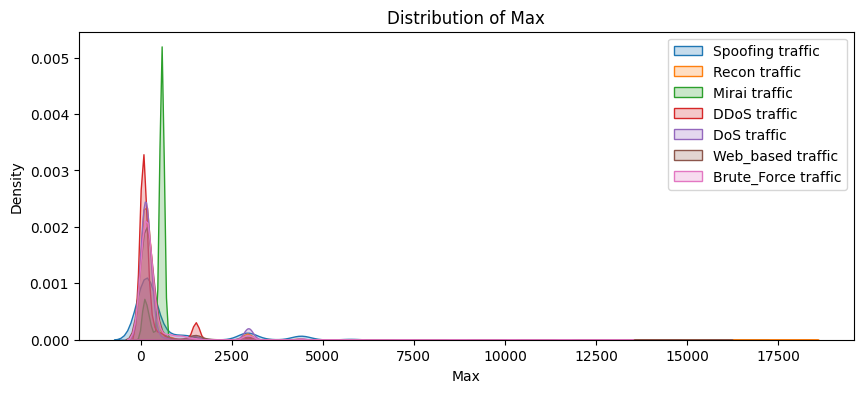

AVG
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


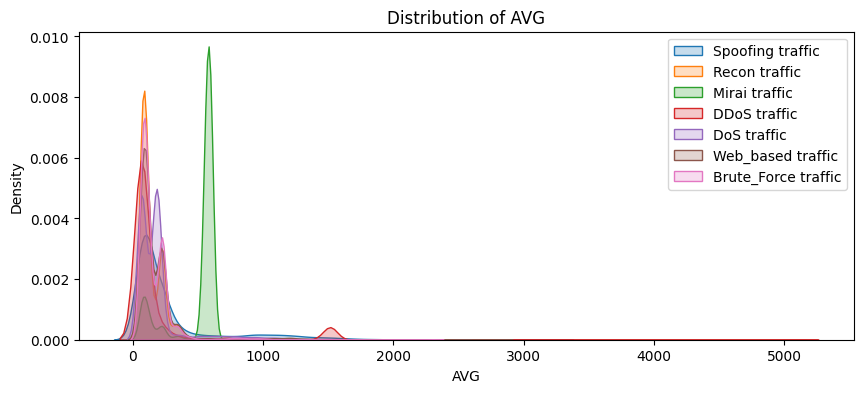

Std
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


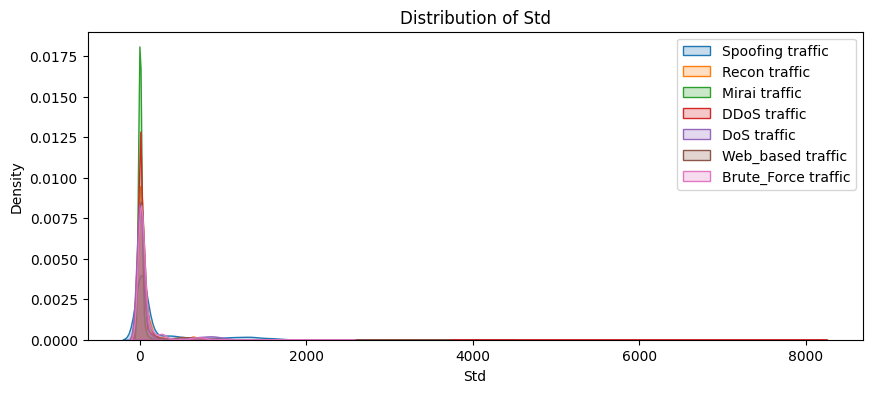

Tot size
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


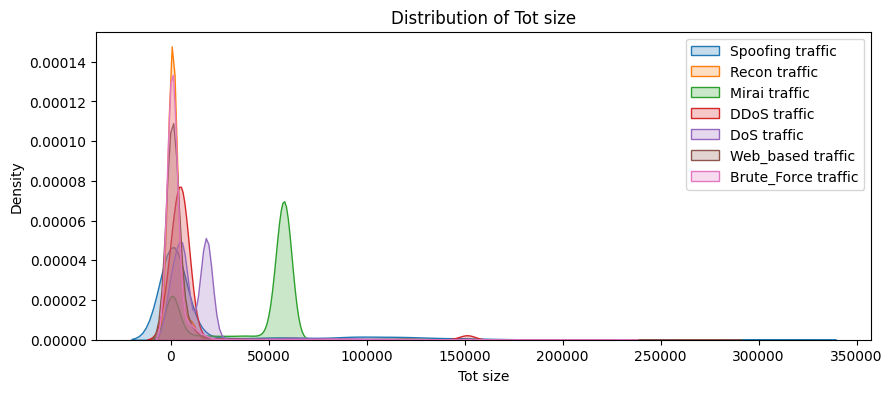

IAT
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


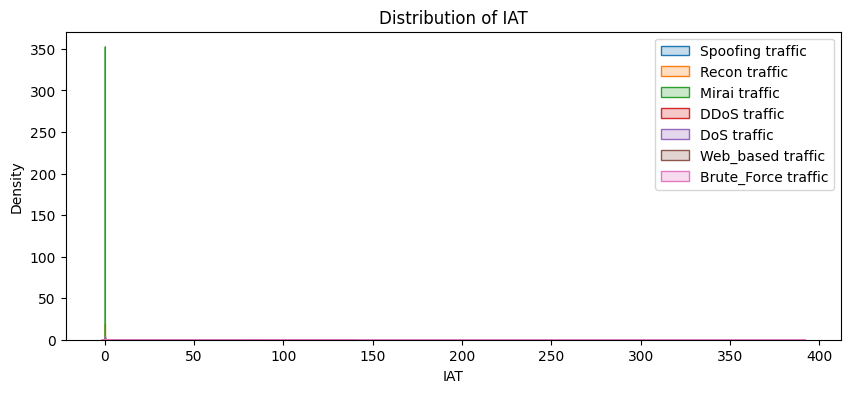

Number
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


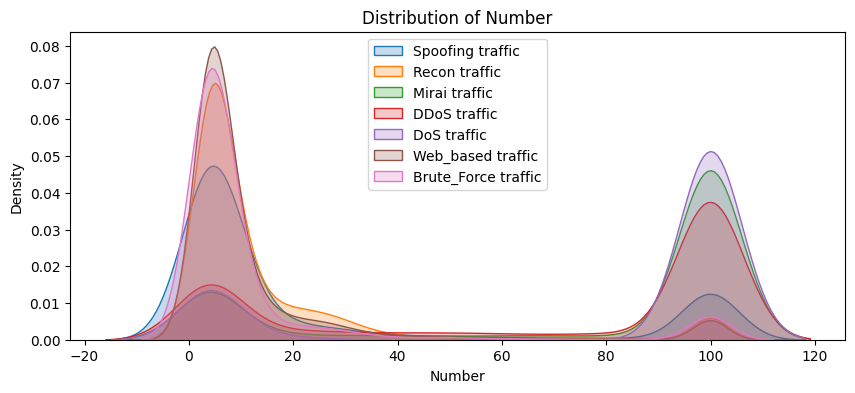

Variance
Spoofing:  12522
Recon:  12522
Mirai:  12522
DDoS:  12522
DoS:  12522
Web_based:  12522
Brute_Force:  8733


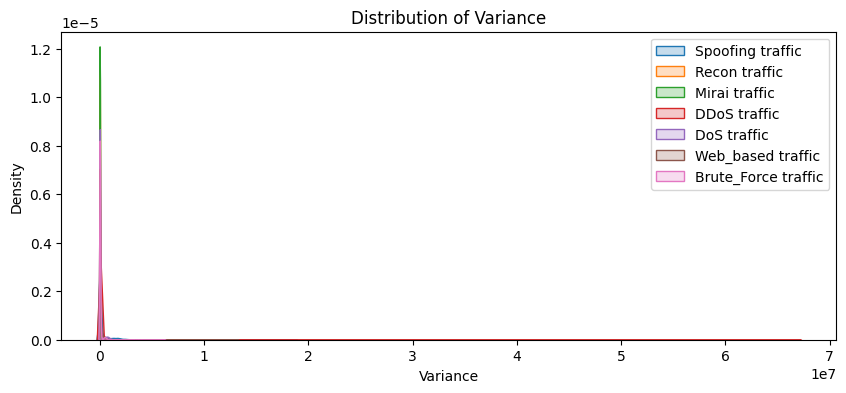

In [87]:
for col in X_dist_test:
    print(col)
    print("Spoofing: ", len(Spoofing[:12522][col]))
    print("Recon: ", len(Recon[:12522][col]))
    print("Mirai: ", len(Mirai[:12522][col]))
    print("DDoS: ", len(DDoS[:12522][col]))
    print("DoS: ", len(DoS[:12522][col]))
    print("Web_based: ", len(Web_based[:12522][col]))
    print("Brute_Force: ", len(Brute_Force[:12522][col]))
    plt.figure(figsize=(10,4))
    sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
    sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)
    sns.kdeplot(Mirai[:12522][col], label='Mirai traffic', fill=True)
    sns.kdeplot(DDoS[:12522][col], label='DDoS traffic', fill=True)
    sns.kdeplot(DoS[:12522][col], label='DoS traffic', fill=True)
    sns.kdeplot(Web_based[:12522][col], label='Web_based traffic', fill=True)
    sns.kdeplot(Brute_Force[:12522][col], label='Brute_Force traffic', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

In [52]:
def limit(data):
    limits = round(data.shape[0]*90/100)
    return limits

attack_train = pd.concat([DDoS[0:limit(DDoS)], DoS[0:limit(DoS)], Mirai[0:limit(Mirai)], Web_based[0:limit(Web_based)], 
                          Spoofing[0:limit(Spoofing)], Recon[0:limit(Recon)], Brute_Force[0:limit(Brute_Force)]], axis=0, ignore_index=True)
attack_train = attack_train.drop(columns=['ICMP', 'IGMP', 'IPv', 'ARP', 'LLC', 'SMTP', 'Telnet', 'ece_flag_number', 'cwr_flag_number', 'DHCP', 'IRC', 'SSH', 'fin_count', 'DNS', 'fin_flag_number', 'TCP', 'HTTP', 'rst_count'])
print("Training attack data: ",attack_train.shape)


attack_test = pd.concat([DDoS[limit(DDoS):DDoS.shape[0]], DoS[limit(DoS):DoS.shape[0]], Mirai[limit(Mirai):Mirai.shape[0]], 
                         Web_based[limit(Web_based):Web_based.shape[0]], Spoofing[limit(Spoofing):Spoofing.shape[0]], 
                         Recon[limit(Recon):Recon.shape[0]], Brute_Force[limit(Brute_Force):Brute_Force.shape[0]]], axis=0, ignore_index=True)
attack_test = attack_test.drop(columns=['ICMP', 'IGMP', 'IPv', 'ARP', 'LLC', 'SMTP', 'Telnet', 'ece_flag_number', 'cwr_flag_number', 'DHCP', 'IRC', 'SSH', 'fin_count', 'DNS', 'fin_flag_number', 'TCP', 'HTTP', 'rst_count'])
print("Testing attack data: ",attack_test.shape)

Training attack data:  (1270795, 22)
Testing attack data:  (141199, 22)


In [ ]:
attack_train

In [ ]:
# Train set preprocessing
attack_train.drop_duplicates(keep='first', inplace = True)
attack_train.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_train.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_train.reset_index(drop=True, inplace=True)

In [53]:
# Create test data
X_train_val = attack_train.drop(columns=['Label'])
Y_train_val = attack_train['Label']

In [54]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
sample_limit = label_series.value_counts()[2]
print(label_series.value_counts())
print(sample_limit)

Label
DDoS           270000
DoS            270000
Mirai          270000
Recon          270000
Spoofing       168487
Web_based       14448
Brute_Force      7860
Name: count, dtype: int64
270000


In [ ]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy={'Recon':sample_limit, 'Spoofing':sample_limit}) # if the sampling_strategy='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded


X_train_val, Y_train_val = undersample.fit_resample(X_train_val, Y_train_val)

In [66]:
# Over sampling
sm = SMOTE()
X_train_val, Y_train_val = sm.fit_resample(X_train_val, Y_train_val)

print(Y_train_val.shape)
print(X_train_val.shape)

(1890000,)
(1890000, 21)


In [67]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
DDoS           270000
DoS            270000
Mirai          270000
Web_based      270000
Spoofing       270000
Recon          270000
Brute_Force    270000
Name: count, dtype: int64


In [68]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_val)

In [69]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_scaled, Y_train_val, test_size=0.2, random_state=33, shuffle=True)

In [70]:
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=20,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=15,   # Reduce splits on small nodes
                                    min_samples_leaf=15,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(X_train, Y_train)

y_pred_frst = frst_model.predict(X_val)
print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

 Brute_Force       0.65      0.81      0.73     53818
        DDoS       0.88      0.77      0.82     54054
         DoS       0.84      0.82      0.83     54187
       Mirai       0.92      0.88      0.90     53851
       Recon       0.66      0.71      0.68     54170
    Spoofing       0.74      0.66      0.70     53964
   Web_based       0.70      0.68      0.69     53956

    accuracy                           0.76    378000
   macro avg       0.77      0.76      0.76    378000
weighted avg       0.77      0.76      0.76    378000



In [58]:
'''
n_estimators=100,       
max_depth=25,           
min_samples_split=15,   
min_samples_leaf=15,    
max_features='sqrt',    
n_jobs=-1,              
#verbose=1,              
random_state=42
'''

y_pred_frst = frst_model.predict(X_val)
print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

 Brute_Force       0.99      0.05      0.10      1583
        DDoS       0.87      0.79      0.83     53868
         DoS       0.82      0.84      0.83     54024
       Mirai       0.92      0.89      0.90     53980
       Recon       0.79      0.92      0.85     54073
    Spoofing       0.72      0.73      0.72     33719
   Web_based       0.79      0.10      0.18      2912

    accuracy                           0.83    254159
   macro avg       0.84      0.62      0.63    254159
weighted avg       0.83      0.83      0.82    254159



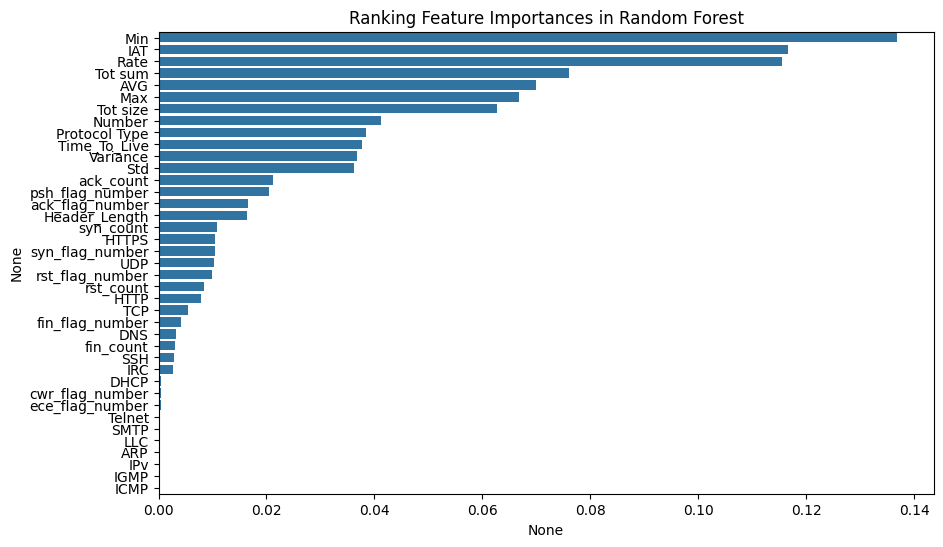

In [85]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Ranking Feature Importances in Random Forest")
plt.show()

In [74]:
# Save the model
with open('../Models/CIC_models/new_frst_model_2nd_stage.pkl', 'wb') as f:
    pickle.dump(frst_model, f)

In [ ]:
# Load the model
with open('../Models/CIC_models/frst_model_2nd_stage.pkl', 'rb') as f:
    frst_model = pickle.load(f)

In [73]:
def limit(data):
    limits = round(data.shape[0]*90/100)
    return limits

attack_sample = Mirai[limit(Mirai):Mirai.shape[0]].drop(columns=['ICMP', 'IGMP', 'IPv', 'ARP', 'LLC', 'SMTP', 'Telnet', 'ece_flag_number', 'cwr_flag_number', 'DHCP', 'IRC', 'SSH', 'fin_count', 'DNS', 'fin_flag_number', 'TCP', 'HTTP', 'rst_count'])
# attack_sample = attack_test
# attack_sample = pd.read_csv('C:/Users/ADMIN/Downloads/DDoS-HTTP_Flood-.pcap.csv', encoding='cp1252', index_col=None, header=0)

# Test set preprocessing
# attack_sample.drop_duplicates(keep='first', inplace = True)
# attack_sample.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
# attack_sample.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
# attack_sample.reset_index(drop=True, inplace=True)

# X_sample = attack_sample
X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

score = 0
total = 200

for i in range(total):
    # sample = X_test.iloc[[len(attack_sample) - i]]  # Must be 2D
    sample = X_sample_scaled[- i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[- i]

    if pred == actual:
        score += 1

    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")
    # print(f"Sample {i}: Predicted = {pred}")

print("Percentage: ", (score/total)*100)

Sample 0: Predicted = Spoofing, Actual = Mirai
Sample 1: Predicted = Mirai, Actual = Mirai
Sample 2: Predicted = Spoofing, Actual = Mirai
Sample 3: Predicted = Spoofing, Actual = Mirai
Sample 4: Predicted = Mirai, Actual = Mirai
Sample 5: Predicted = Spoofing, Actual = Mirai
Sample 6: Predicted = Mirai, Actual = Mirai
Sample 7: Predicted = Mirai, Actual = Mirai
Sample 8: Predicted = Spoofing, Actual = Mirai
Sample 9: Predicted = Mirai, Actual = Mirai
Sample 10: Predicted = Spoofing, Actual = Mirai
Sample 11: Predicted = Mirai, Actual = Mirai
Sample 12: Predicted = Mirai, Actual = Mirai
Sample 13: Predicted = Spoofing, Actual = Mirai
Sample 14: Predicted = Spoofing, Actual = Mirai
Sample 15: Predicted = Brute_Force, Actual = Mirai
Sample 16: Predicted = Mirai, Actual = Mirai
Sample 17: Predicted = DDoS, Actual = Mirai
Sample 18: Predicted = Mirai, Actual = Mirai
Sample 19: Predicted = Mirai, Actual = Mirai
Sample 20: Predicted = Spoofing, Actual = Mirai
Sample 21: Predicted = Mirai, Act

### Model train on Normal traffic only (Unsupervised learning)

Unsupervised learning for Anomaly Detection using One-Class Classification (or Novelty Detection)

In [ ]:
model = IsolationForest(n_estimators=1000,       # Number of trees in the forest
                            max_samples='auto',        # Number of samples to draw for each tree (sub-sampling)
                            contamination='auto',   
                            random_state=42,
                            n_jobs=-1)              # Use all CPU cores
model.fit(X_train_scaled)

Unsupervised learning for Anomaly Detection using Autoencoder

In [ ]:
import keras
from keras.models import Sequential
from keras import Input, optimizers, layers
from keras.layers import *

In [ ]:
_features = X_train_scaled.shape[1]
print(_features)

In [ ]:
model = Sequential([
    Input(shape=(_features,)),
    
    # Autoencoder
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),   # bottleneck
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(512, activation='relu'),

    # Classification layer
    Dense(_features, activation='sigmoid'),  # Softmax for multiclass, Sigmoid for binary, both use as output layer
])

In [ ]:
model.summary()

In [ ]:
opt = optimizers.Adam(learning_rate=0.0001)
# model.compile(loss='mse', optimizer=opt, metrics=[keras.metrics.F1Score(average=None, threshold=None, name="f1_score", dtype=None)])
model.compile(loss='mse', optimizer=opt)
early_stop_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=5)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                  patience=3, min_lr=0.0001)

In [ ]:
start_fit = time.time()
history = model.fit(X_train_scaled, X_train_scaled,
                    batch_size=256,
                    epochs=50,
                    verbose=True,
                    validation_split= 0.1)    

end_fit = time.time()
fit_time = end_fit - start_fit
print("fit time: {:.2f} seconds".format(fit_time)) 

In [ ]:
#Let's try to get latent learnt representation by autoencoder
hidden_representation = Sequential()
hidden_representation.add(model.layers[0])
hidden_representation.add(model.layers[1])
hidden_representation.add(model.layers[2])
hidden_representation.add(model.layers[3])

In [ ]:
hidden_representation.summary()

In [ ]:
attack_test.drop_duplicates(keep='first', inplace = True)
attack_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_test.reset_index(drop=True, inplace=True)

# attack_test = attack_test.drop(columns=['Tot size', 'Protocol Type'])
# attack_test = attack_test.drop(columns=['Label'])

# # Grouping
# Attack = ['DDoS', 'Web_based', 'DoS', 'Brute_Force', 'Recon', 'Spoofing', 'Mirai']
# def classify_attacks(data):
#     data['Label'].replace(Attack,1,inplace=True)
# classify_attacks(attack_test)

normal_test.drop_duplicates(keep='first', inplace = True)
normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal_test.reset_index(drop=True, inplace=True)

# normal_test = normal_test.drop(columns=['Tot size', 'Protocol Type'])
# normal_test = normal_test.drop(columns=['Label'])

norm_hid_rep = hidden_representation.predict(normal_test)
fraud_hid_rep = hidden_representation.predict(attack_test)

In [ ]:
from sklearn.manifold import TSNE

def tsne_plot(x1, y1, name="graph.png"):
    
    #Scale features to improve the training ability of TSNE.
    standard_scaler = StandardScaler()
    df2_std = standard_scaler.fit_transform(x1)

    tsne = TSNE(n_components=2, random_state=0)
    x_test_2d = tsne.fit_transform(df2_std)
    
    #Build the scatter plot with the two types of transactions.
    color_map = {0:'green', 1:'red'}
    plt.figure()
    for idx, cl in enumerate(np.unique(y1)):
        plt.scatter(x = x_test_2d[y1==cl,0], 
                    y = x_test_2d[y1==cl,1], 
                    c = color_map[idx], 
                    label = cl)
    plt.xlabel('X in t-SNE')
    plt.ylabel('Y in t-SNE')
    plt.legend(loc='upper left')
    plt.title('t-SNE visualization of test data')
    plt.show()

In [ ]:
#Let's try to visualize TSNE again for the learnt representation
rep_x = np.append(norm_hid_rep, fraud_hid_rep, axis = 0)
y_n = np.zeros(norm_hid_rep.shape[0])
y_f = np.ones(fraud_hid_rep.shape[0])
rep_y = np.append(y_n, y_f)

tsne_plot(rep_x, rep_y)

In [ ]:
#Finally we can train a classifier on learnt representations

train_x, val_x, train_y, val_y = train_test_split(rep_x, rep_y, test_size=0.25)
clf = LogisticRegression(solver="lbfgs").fit(train_x, train_y)
pred_y = clf.predict(val_x)

print ("")
print ("Classification Report: ")
print (classification_report(val_y, pred_y))

print ("")
print ("Accuracy Score: ", accuracy_score(val_y, pred_y))

In [ ]:
#Finally we can train a classifier on learnt representations

train_x, val_x, train_y, val_y = train_test_split(rep_x, rep_y, test_size=0.25)
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=20,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=20,   # Reduce splits on small nodes
                                    min_samples_leaf=20,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(train_x, train_y)
pred_y = frst_model.predict(val_x)

print ("")
print ("Classification Report: ")
print (classification_report(val_y, pred_y))

print ("")
print ("Accuracy Score: ", accuracy_score(val_y, pred_y))

In [ ]:
# sample_set = attack_test
sample_set = normal_test

# Test set preprocessing
sample_set.drop_duplicates(keep='first', inplace = True)
sample_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
sample_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
sample_set.reset_index(drop=True, inplace=True)

X_sample = sample_set.drop(columns=['Label'])
# X_sample = sample_set.drop(columns=['Label', 'Tot size', 'Protocol Type'])
# Y_sample = sample_set['Label']

X_sample_scaled = scaler.fit_transform(X_sample)

# Step 1: Get reconstruction errors on validation normal traffic
val_reconstructions = model.predict(X_sample_scaled)
val_mse = np.mean(np.power(X_sample_scaled - val_reconstructions, 2), axis=1)

# Step 2: Compute threshold (e.g., 95th percentile)
threshold = np.percentile(val_mse, 50)
print(f"Anomaly Detection Threshold (95th percentile): {threshold:.6f}")

# Step 3: Loop through test samples to classify
for i in range(100):
    # Get i-th test sample (already scaled)
    sample = X_sample_scaled[i].reshape(1, -1)

    # Predict reconstruction
    reconstruction = model.predict(sample)

    # Calculate reconstruction error (MSE)
    mse = np.mean(np.power(sample - reconstruction, 2))

    # Decision based on threshold
    label = "Anomaly Detected!" if mse > threshold else "Normal Traffic."
    
    print(f"Sample {i}: MSE = {mse:.6f} --> {label}")


In [ ]:
# test_set = pd.read_csv('../Label CSV/BENIGN.csv')
# test_set = pd.read_csv('../Label CSV/Mirai.csv')
# test_set = pd.read_csv('../Label CSV/Brute_Force.csv')
# test_set = pd.read_csv('../Label CSV/DDoS.csv')
# test_set = pd.read_csv('../Label CSV/DoS.csv')
# test_set = pd.read_csv('../Label CSV/Recon.csv')
# test_set = pd.read_csv('../Label CSV/Spoofing.csv')
# test_set = pd.read_csv('../Label CSV/Web_based.csv')
test_set = normal_train

# Test set preprocessing
test_set.drop_duplicates(keep='first', inplace = True)
test_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
test_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
test_set.reset_index(drop=True, inplace=True)
test_set = test_set

X_normal_sample = test_set.drop(columns=['Tot size', 'Protocol Type'])
# X_normal_sample = test_set.drop(columns=['Label'])
# Y_normal_sample = test_set['Label']

X_normal_sample_scaled = scaler.fit_transform(X_normal_sample)

for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_normal_sample_scaled[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    # actual = Y_normal_sample.iloc[i]

    print(f"Sample {i}: Predicted = {pred}")
    # print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

# rand = random.randint(0,len(X_scaled)-1)
# test_data = X_scaled[rand].reshape(1, -1)    #If standard scaler is includeed, always reshape the data

# pred_label = model.predict(test_data)
# print("Predicted class label:", pred_label)
# real_label = Y_test.iloc[rand]
# print("Real class label:", real_label)

In [ ]:
# Test set preprocessing
attack_test.drop_duplicates(keep='first', inplace = True)
attack_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_test.reset_index(drop=True, inplace=True)

X_attack_sample = attack_test.drop(columns=['Label'])
Y_attack_sample = attack_test['Label']

X_attack_sample_scaled = scaler.fit_transform(X_attack_sample)

for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_attack_sample_scaled[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = model.predict(sample)[0]
    actual = Y_attack_sample.iloc[i]

    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

# rand = random.randint(0,len(X_scaled)-1)
# test_data = X_scaled[rand].reshape(1, -1)    #If standard scaler is includeed, always reshape the data

# pred_label = model.predict(test_data)
# print("Predicted class label:", pred_label)
# real_label = Y_test.iloc[rand]
# print("Real class label:", real_label)

If val loss increases while train loss keeps decreasing, it’s overfitting

In [ ]:
# Assuming 'history' is the result from model.fit()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

In [ ]:
sample_set = pd.read_csv('../Label CSV/BENIGN.csv')
# sample_set = pd.read_csv('../Label CSV/Mirai.csv')
# sample_set = pd.read_csv('../Label CSV/Brute_Force.csv')
# sample_set = pd.read_csv('../Label CSV/DDoS.csv')
# sample_set = pd.read_csv('../Label CSV/DoS.csv')
# sample_set = pd.read_csv('../Label CSV/Recon.csv')
# sample_set = pd.read_csv('../Label CSV/Spoofing.csv')
# sample_set = pd.read_csv('../Label CSV/Web_based.csv')
# sample_set = normal_test

# Test set preprocessing
sample_set.drop_duplicates(keep='first', inplace = True)
sample_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
sample_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
sample_set.reset_index(drop=True, inplace=True)

# X_sample = sample_set
X_sample = sample_set.drop(columns=['Label'])
Y_sample = sample_set['Label']

X_sample_scaled = scaler.fit_transform(X_sample)

# # Predict Anomaly (-1 = Anomaly, 1 = Normal)
# predictions = model.predict(X_sample_scaled)

# # Optional: Get anomaly scores (the lower, the more anomalous)
# anomaly_scores = model.decision_function(X_sample_scaled)

# print(predictions)
# print(anomaly_scores)

for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = model.predict(sample)[0]

    print(f"Sample {i}: Predicted = {pred}")

# rand = random.randint(0,len(X_scaled)-1)
# test_data = X_scaled[rand].reshape(1, -1)    #If standard scaler is includeed, always reshape the data

# pred_label = model.predict(test_data)
# print("Predicted class label:", pred_label)
# real_label = Y_test.iloc[rand]
# print("Real class label:", real_label)

In [ ]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top Feature Importances in Random Forest")
plt.show()

In [ ]:
my_benign = pd.read_csv('C:/Users/ADMIN/Downloads/live_features.csv')
my_benign = my_benign.drop(columns=['ts'])
# # print(my_benign.info())
# my_benign = my_benign.drop(columns=['ts', 'fin_count', 'fin_flag_number', 'rst_count', 'rst_flag_number', 'syn_count', 'syn_flag_number', 'Number'])
# # Test set preprocessing
# my_benign.drop_duplicates(keep='first', inplace = True)
# my_benign.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
# my_benign.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
# my_benign.reset_index(drop=True, inplace=True)
# my_benign = scaler.fit_transform(my_benign)

In [ ]:
for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = my_benign[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]

    print(f"Sample {i}: Predicted = {pred}")

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
data_combined = pd.concat([cic_benign, my_benign])
data_scaled = scaler.fit_transform(data_combined)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

labels = np.array(['CIC'] * len(cic_benign) + ['Mine'] * len(my_benign))

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=labels)
plt.title('PCA of Benign Data')
plt.show()